## what rho gives me a limit cycle? parameter sweep for rho. 

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# ----------------------------
# Parameters (fixed)
# ----------------------------
alpha = 1/100
beta = 0.5
gamma = 1/7
epsilon = 1/7
theta = 0.01
kappa = 1000
psi = 0.5

def H(q):
    return 1 / (1 + np.exp(-kappa * q))

def system(t, y, rho_val):
    S, I, v = y
    q = beta * I - rho_val - theta * (1 - 2 * v)
    
    dS = alpha * (psi - S - I) - beta * S * I - epsilon * v * S
    dI = -gamma * I + beta * S * I
    dv = -v + H(q)
    
    return [dS, dI, dv]

# ----------------------------
# Test different rho values
# ----------------------------
print("=" * 70)
print("TESTING DIFFERENT RHO VALUES TO FIND LIMIT CYCLE")
print("=" * 70)

rho_values = [0.01, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02]

# Initial conditions
S0, I0, v0 = 0.49, 0.01, 0.01
y0 = [S0, I0, v0]

print(f"\n{'rho':>6} | {'Peaks':>6} | {'Period':>10} | {'Amplitude':>10} | Status")
print("-" * 70)

for rho_val in rho_values:
    # Integrate for transient
    sol_transient = solve_ivp(
        lambda t, y: system(t, y, rho_val),
        [0, 5000],
        y0,
        rtol=1e-10,
        atol=1e-12,
        max_step=1.0
    )
    
    # Continue from end of transient
    y_start = sol_transient.y[:, -1]
    
    # Integrate for period detection
    sol_period = solve_ivp(
        lambda t, y: system(t, y, rho_val),
        [0, 500],
        y_start,
        dense_output=True,
        max_step=0.1,
        rtol=1e-10,
        atol=1e-12
    )
    
    # Look for peaks in I
    I_vals = sol_period.y[1, :]
    peaks, _ = find_peaks(I_vals, height=0.001, distance=20)
    
    if len(peaks) >= 2:
        # Has oscillations!
        t_vals = sol_period.t
        periods = np.diff(t_vals[peaks])
        T_est = np.mean(periods)
        amplitude = np.max(I_vals) - np.min(I_vals)
        status = "✓ LIMIT CYCLE"
        print(f"{rho_val:6.3f} | {len(peaks):6d} | {T_est:10.2f} | {amplitude:10.6f} | {status}")
    else:
        # No oscillations - probably fixed point
        amplitude = np.max(I_vals) - np.min(I_vals)
        status = "✗ Fixed point" if amplitude < 0.001 else "? Unclear"
        print(f"{rho_val:6.3f} | {len(peaks):6d} | {'N/A':>10} | {amplitude:10.6f} | {status}")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)


TESTING DIFFERENT RHO VALUES TO FIND LIMIT CYCLE

   rho |  Peaks |     Period |  Amplitude | Status
----------------------------------------------------------------------
 0.010 |      2 |     244.29 |   0.033898 | ✓ LIMIT CYCLE
 0.011 |      2 |     244.48 |   0.034654 | ✓ LIMIT CYCLE
 0.012 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.013 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.014 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.015 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.016 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.017 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.018 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.019 |      0 |        N/A |   0.000000 | ✗ Fixed point
 0.020 |      0 |        N/A |   0.000000 | ✗ Fixed point

RECOMMENDATION:


## so move on with rho = 0.011 then

Step 1: Finding the limit cycle...
✓ Transient integration complete (t=0 to 5000)
  Final state: S=0.275011, I=0.000117, v=0.000000

Step 2: Estimating period...
✓ Found 2 peaks
  Estimated period T ≈ 244.4822

Step 3: Computing one clean period...
Using n_points = 10000 for high accuracy near switching boundaries...
✓ One period computed with 10000 points
  Period T = 244.4822
  Starting point: S=0.285587, I=0.034770, v=0.076460
  Ending point:   S=0.285506, I=0.034770, v=0.076898
  Periodicity error: 4.45e-04
  ⚠ Warning: Periodicity error is larger than desired!
     This may affect iPRC calculation accuracy.

Step 4: Visualizing...


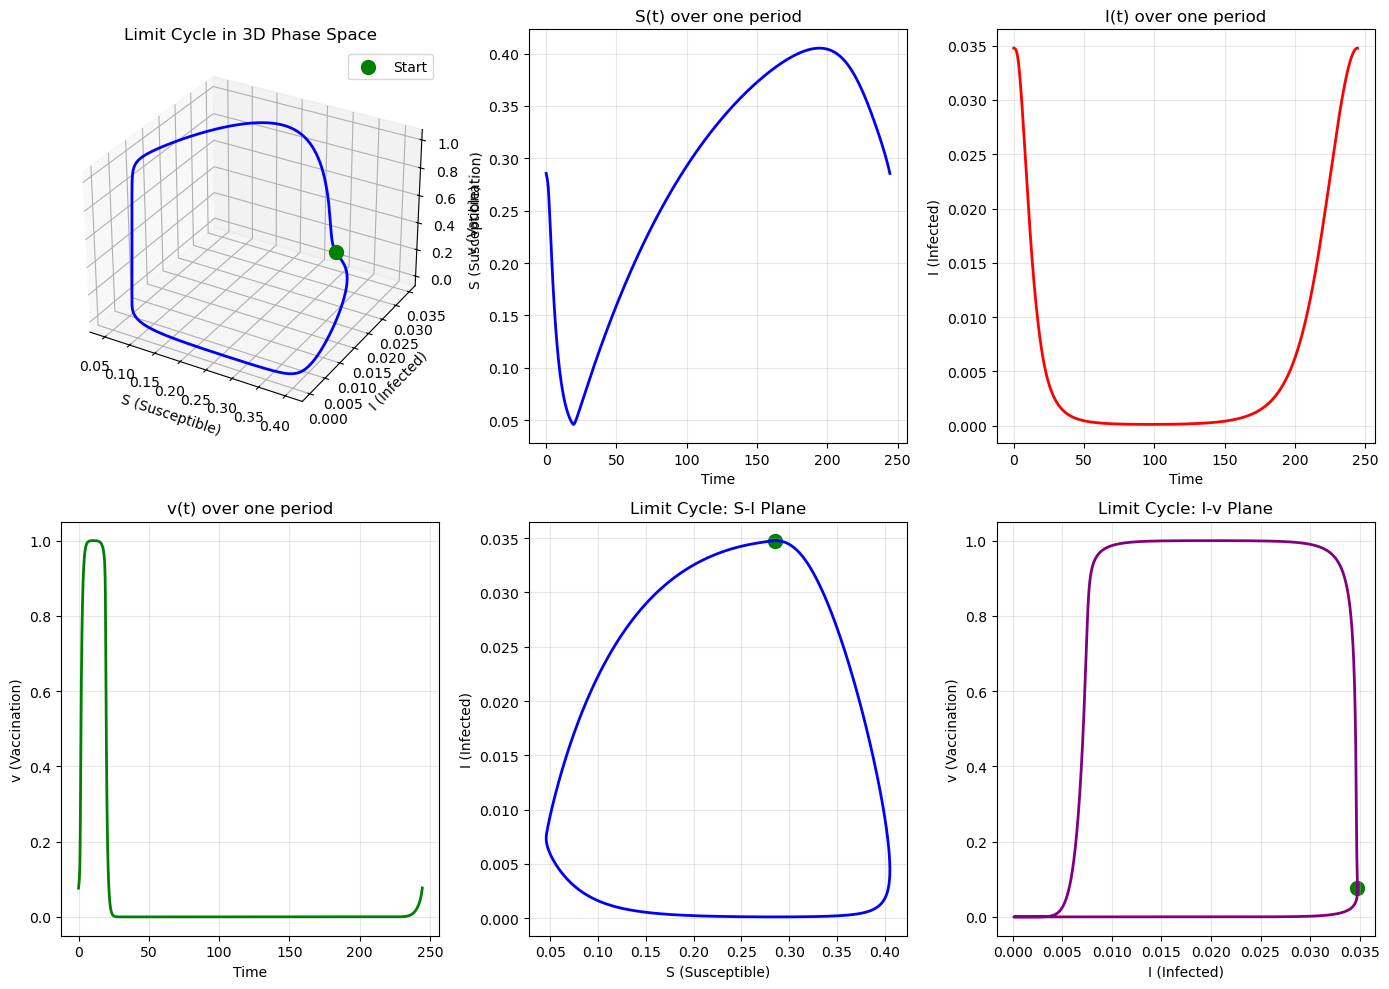


SUCCESS! Limit cycle computed and stored in 'Gamma'

Parameters used:
  rho = 0.011
  n_points = 10000
  Period T = 244.4822
  Periodicity error = 4.45e-04


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------
# Parameters
# ----------------------------
alpha = 1/100
beta = 0.5
gamma = 1/7
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.011  # ← CHANGED from 0.01 to 0.011
psi = 0.5

# Smooth Heaviside function
def H(q):
    return 1 / (1 + np.exp(-kappa * q))

# ----------------------------
# System of ODEs
# ----------------------------
def system(t, y):
    S, I, v = y
    q = beta * I - rho - theta * (1 - 2 * v)
    
    dS = alpha * (psi - S - I) - beta * S * I - epsilon * v * S
    dI = -gamma * I + beta * S * I
    dv = -v + H(q)
    
    return [dS, dI, dv]

# ----------------------------
# Step 1: Integrate for a long time to reach limit cycle
# ----------------------------
print("Step 1: Finding the limit cycle...")
print("=" * 60)

# Initial conditions
S0, I0, v0 = 0.49, 0.01, 0.01
y0 = [S0, I0, v0]

# Integrate for a long time to let transients die out
t_transient = 5000  # integrate for long time
sol_transient = solve_ivp(
    system, 
    [0, t_transient], 
    y0,
    dense_output=True,
    rtol=1e-10,
    atol=1e-12
)

print(f"✓ Transient integration complete (t=0 to {t_transient})")
print(f"  Final state: S={sol_transient.y[0,-1]:.6f}, I={sol_transient.y[1,-1]:.6f}, v={sol_transient.y[2,-1]:.6f}")

# ----------------------------
# Step 2: Find the period by detecting crossings
# ----------------------------
print("\nStep 2: Estimating period...")
print("=" * 60)

# Start from end of transient and integrate more
y_start = sol_transient.y[:, -1]
t_span_period = 500
sol_period = solve_ivp(
    system,
    [0, t_span_period],
    y_start,
    dense_output=True,
    max_step=0.1,
    rtol=1e-10,
    atol=1e-12
)

# Find period by looking for when I returns to same value
# (detecting maxima of I)
I_vals = sol_period.y[1, :]
t_vals = sol_period.t

# Find local maxima (peaks)
from scipy.signal import find_peaks
peaks, _ = find_peaks(I_vals, height=0.01, distance=50)

if len(peaks) >= 2:
    # Estimate period from peak spacing
    periods = np.diff(t_vals[peaks])
    T_estimated = np.mean(periods)
    print(f"✓ Found {len(peaks)} peaks")
    print(f"  Estimated period T ≈ {T_estimated:.4f}")
else:
    print("⚠ Warning: Could not detect clear peaks. Using default estimate.")
    T_estimated = 100.0

# ----------------------------
# Step 3: Integrate for exactly one period WITH MORE POINTS
# ----------------------------
print("\nStep 3: Computing one clean period...")
print("=" * 60)

# Start fresh from the limit cycle
y_start_clean = sol_period.y[:, peaks[0]] if len(peaks) > 0 else y_start

# Integrate for one period with MANY MORE points
n_points = 10000  # ← CHANGED from 1000 to 10000
t_one_period = np.linspace(0, T_estimated, n_points)

print(f"Using n_points = {n_points} for high accuracy near switching boundaries...")

sol_one_period = solve_ivp(
    system,
    [0, T_estimated],
    y_start_clean,
    t_eval=t_one_period,
    rtol=1e-10,
    atol=1e-12
)

# Store as Gamma (your limit cycle)
Gamma = np.zeros((n_points, 4))  # [time, S, I, v]
Gamma[:, 0] = sol_one_period.t
Gamma[:, 1] = sol_one_period.y[0, :]  # S
Gamma[:, 2] = sol_one_period.y[1, :]  # I
Gamma[:, 3] = sol_one_period.y[2, :]  # v

print(f"✓ One period computed with {n_points} points")
print(f"  Period T = {T_estimated:.4f}")
print(f"  Starting point: S={Gamma[0,1]:.6f}, I={Gamma[0,2]:.6f}, v={Gamma[0,3]:.6f}")
print(f"  Ending point:   S={Gamma[-1,1]:.6f}, I={Gamma[-1,2]:.6f}, v={Gamma[-1,3]:.6f}")

# Check if it's actually periodic (start ≈ end)
error = np.linalg.norm(Gamma[0, 1:] - Gamma[-1, 1:])
print(f"  Periodicity error: {error:.2e}")

if error > 1e-6:
    print(f"  ⚠ Warning: Periodicity error is larger than desired!")
    print(f"     This may affect iPRC calculation accuracy.")
else:
    print(f"  ✓ Excellent periodicity!")

# ----------------------------
# Step 4: Visualize the limit cycle
# ----------------------------
print("\nStep 4: Visualizing...")
print("=" * 60)

fig = plt.figure(figsize=(14, 10))

# 3D phase space
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.plot(Gamma[:, 1], Gamma[:, 2], Gamma[:, 3], 'b-', linewidth=2)
ax1.scatter(Gamma[0, 1], Gamma[0, 2], Gamma[0, 3], c='green', s=100, marker='o', label='Start')
ax1.set_xlabel('S (Susceptible)')
ax1.set_ylabel('I (Infected)')
ax1.set_zlabel('v (Vaccination)')
ax1.set_title('Limit Cycle in 3D Phase Space')
ax1.legend()

# Time series - S
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(Gamma[:, 0], Gamma[:, 1], 'b-', linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('S (Susceptible)')
ax2.set_title('S(t) over one period')
ax2.grid(True, alpha=0.3)

# Time series - I
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(Gamma[:, 0], Gamma[:, 2], 'r-', linewidth=2)
ax3.set_xlabel('Time')
ax3.set_ylabel('I (Infected)')
ax3.set_title('I(t) over one period')
ax3.grid(True, alpha=0.3)

# Time series - v
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(Gamma[:, 0], Gamma[:, 3], 'g-', linewidth=2)
ax4.set_xlabel('Time')
ax4.set_ylabel('v (Vaccination)')
ax4.set_title('v(t) over one period')
ax4.grid(True, alpha=0.3)

# S-I plane
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(Gamma[:, 1], Gamma[:, 2], 'b-', linewidth=2)
ax5.scatter(Gamma[0, 1], Gamma[0, 2], c='green', s=100, marker='o')
ax5.set_xlabel('S (Susceptible)')
ax5.set_ylabel('I (Infected)')
ax5.set_title('Limit Cycle: S-I Plane')
ax5.grid(True, alpha=0.3)

# I-v plane
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(Gamma[:, 2], Gamma[:, 3], 'purple', linewidth=2)
ax6.scatter(Gamma[0, 2], Gamma[0, 3], c='green', s=100, marker='o')
ax6.set_xlabel('I (Infected)')
ax6.set_ylabel('v (Vaccination)')
ax6.set_title('Limit Cycle: I-v Plane')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUCCESS! Limit cycle computed and stored in 'Gamma'")
print("=" * 60)
print(f"\nParameters used:")
print(f"  rho = {rho}")
print(f"  n_points = {n_points}")
print(f"  Period T = {T_estimated:.4f}")
print(f"  Periodicity error = {error:.2e}")


## Calculate Jacobian, plug in Gamma(t) and get A(t)

STEP 2A: Computing Jacobian A(t)

Computing Jacobian at 10000 points along limit cycle...
✓ Jacobian computed at all points!

Sanity check - A(t) at a few time points:
------------------------------------------------------------

Time t = 0.00:
  State: S=0.2856, I=0.0348, v=0.0765
  A(t) =
[[-3.83078243e-02 -1.52793387e-01 -4.07981105e-02]
 [ 1.73849433e-02 -6.37562615e-05  0.00000000e+00]
 [ 0.00000000e+00  4.91368608e+01  9.65474432e-01]]

Time t = 61.13:
  State: S=0.1951, I=0.0002, v=0.0000
  A(t) =
[[-1.01234164e-02 -1.07535709e-01 -2.78673456e-02]
 [ 1.23416307e-04 -4.53214334e-02  0.00000000e+00]
 [ 0.00000000e+00  4.28928508e-07 -9.99999983e-01]]

Time t = 122.25:
  State: S=0.3336, I=0.0002, v=0.0000
  A(t) =
[[-1.00795798e-02 -1.76795087e-01 -4.76557391e-02]
 [ 7.95797162e-05  2.39379440e-02  0.00000000e+00]
 [ 0.00000000e+00  4.10531912e-07 -9.99999984e-01]]

Time t = 183.38:
  State: S=0.4023, I=0.0023, v=0.0000
  A(t) =
[[-1.11612006e-02 -2.11152504e-01 -5.74721441e-02]
 

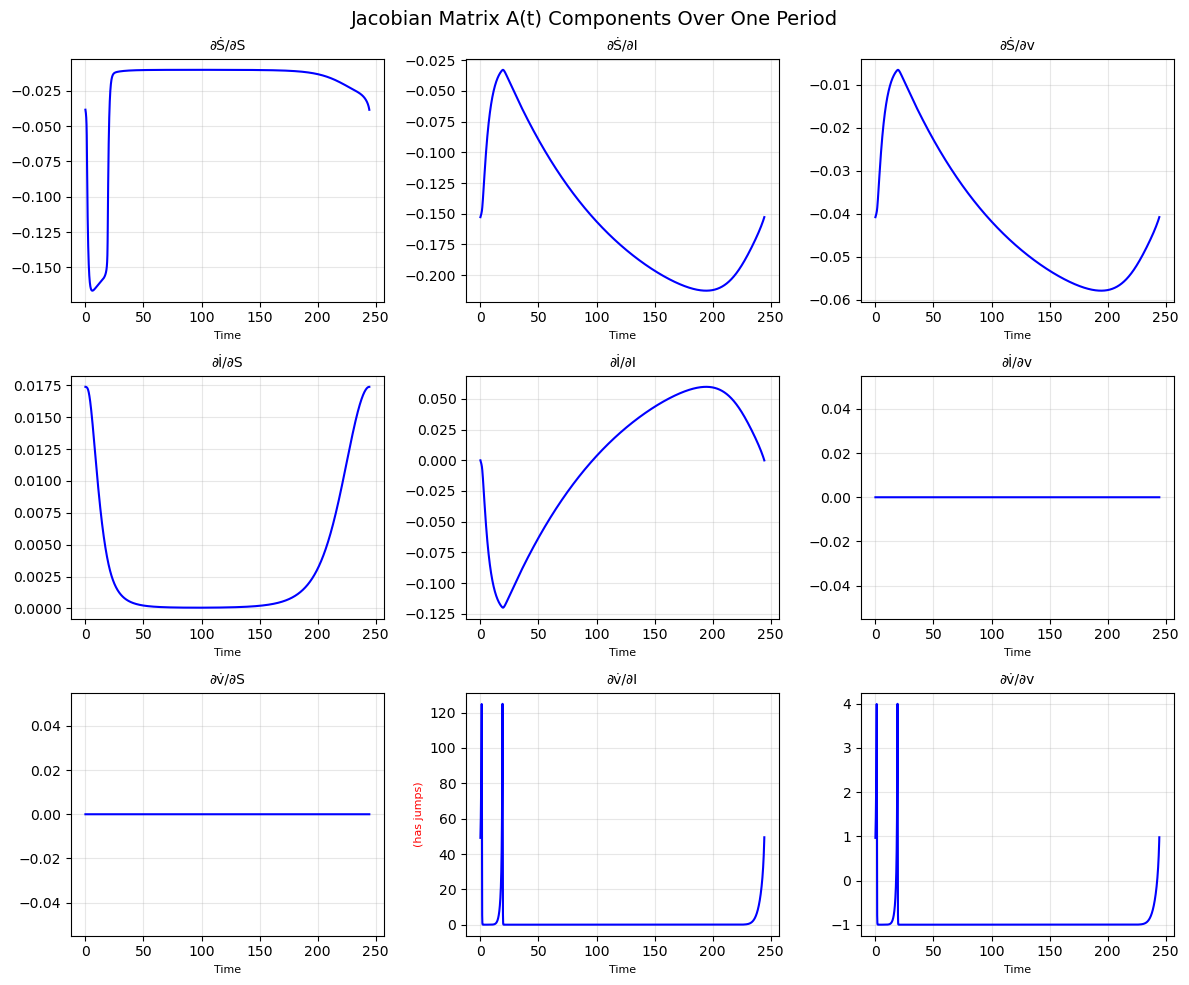


STEP 2A COMPLETE!
✓ We now have A_trajectory with shape: (10000, 3, 3)
  This contains A(t) at each point on the limit cycle

Next: Step 2B - Detect switching surface crossings


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we already have:
# - Gamma: array of shape (n_points, 4) with columns [time, S, I, v]
# - T_estimated: the period
# - All parameters: alpha, beta, gamma, epsilon, theta, kappa, rho, psi

# ----------------------------
# Parameters (copy from before)
# ----------------------------
alpha = 1/100
beta = 0.5
gamma_param = 1/7  # renamed to avoid conflict with Gamma array
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.011  # ← CHANGED from 0.01 to 0.011
psi = 0.5

print("=" * 60)
print("STEP 2A: Computing Jacobian A(t)")
print("=" * 60)

# ----------------------------
# Derivatives of H(q) with respect to q
# ----------------------------
def H(q):
    """Smooth Heaviside"""
    return 1 / (1 + np.exp(-kappa * q))

def dH_dq(q):
    """Derivative of H with respect to q"""
    exp_term = np.exp(-kappa * q)
    return kappa * exp_term / (1 + exp_term)**2

# ----------------------------
# Compute Jacobian A at a single point (S, I, v)
# ----------------------------
def compute_jacobian(S, I, v):
    """
    Compute the Jacobian matrix A = DF evaluated at (S, I, v)
    
    The system is:
        dS/dt = alpha*(psi - S - I) - beta*S*I - epsilon*v*S
        dI/dt = -gamma*I + beta*S*I
        dv/dt = -v + H(q),  where q = beta*I - rho - theta*(1 - 2*v)
    
    Returns: 3x3 numpy array
    """
    # First, compute q and dH/dq at this point
    q = beta * I - rho - theta * (1 - 2 * v)
    dH_dq_val = dH_dq(q)
    
    # Now compute all partial derivatives
    # Row 1: derivatives of dS/dt
    dS_dS = -alpha - beta * I - epsilon * v
    dS_dI = -alpha - beta * S
    dS_dv = -epsilon * S
    
    # Row 2: derivatives of dI/dt
    dI_dS = beta * I
    dI_dI = -gamma_param + beta * S
    dI_dv = 0
    
    # Row 3: derivatives of dv/dt
    # dv/dt = -v + H(q), where q = beta*I - rho - theta*(1 - 2*v)
    # So: ∂(dv/dt)/∂S = 0
    #     ∂(dv/dt)/∂I = dH/dq * ∂q/∂I = dH/dq * beta
    #     ∂(dv/dt)/∂v = -1 + dH/dq * ∂q/∂v = -1 + dH/dq * 2*theta
    
    dv_dS = 0
    dv_dI = dH_dq_val * beta
    dv_dv = -1 + dH_dq_val * 2 * theta
    
    # Assemble the Jacobian
    A = np.array([
        [dS_dS, dS_dI, dS_dv],
        [dI_dS, dI_dI, dI_dv],
        [dv_dS, dv_dI, dv_dv]
    ])
    
    return A

# ----------------------------
# Compute A(t) for all points on the limit cycle
# ----------------------------
n_points = Gamma.shape[0]
A_trajectory = np.zeros((n_points, 3, 3))

print(f"\nComputing Jacobian at {n_points} points along limit cycle...")

for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    
    A_trajectory[i, :, :] = compute_jacobian(S_i, I_i, v_i)

print("✓ Jacobian computed at all points!")

# ----------------------------
# Sanity check: show A at a few points
# ----------------------------
print("\nSanity check - A(t) at a few time points:")
print("-" * 60)

for idx in [0, n_points//4, n_points//2, 3*n_points//4]:
    print(f"\nTime t = {Gamma[idx, 0]:.2f}:")
    print(f"  State: S={Gamma[idx, 1]:.4f}, I={Gamma[idx, 2]:.4f}, v={Gamma[idx, 3]:.4f}")
    print(f"  A(t) =")
    print(A_trajectory[idx])

# ----------------------------
# Visualize one element of A(t) over time
# ----------------------------
print("\nVisualizing A(t) components over time...")

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Jacobian Matrix A(t) Components Over One Period', fontsize=14)

component_names = [
    ['∂Ṡ/∂S', '∂Ṡ/∂I', '∂Ṡ/∂v'],
    ['∂İ/∂S', '∂İ/∂I', '∂İ/∂v'],
    ['∂v̇/∂S', '∂v̇/∂I', '∂v̇/∂v']
]

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.plot(Gamma[:, 0], A_trajectory[:, i, j], 'b-', linewidth=1.5)
        ax.set_title(component_names[i][j], fontsize=10)
        ax.set_xlabel('Time', fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Highlight if there are jumps (near switching surface)
        if np.max(np.abs(np.diff(A_trajectory[:, i, j]))) > 1:
            ax.set_ylabel('(has jumps)', fontsize=8, color='red')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("STEP 2A COMPLETE!")
print("=" * 60)
print("✓ We now have A_trajectory with shape:", A_trajectory.shape)
print("  This contains A(t) at each point on the limit cycle")
print("\nNext: Step 2B - Detect switching surface crossings")

## Next: Step 2B - Detect switching surface crossings

STEP 2B: Detecting Switching Surface Crossings

Computing q(t) = βI - ρ - θ(1 - 2v) along limit cycle...
✓ Computed q(t) at 10000 points
  Range: [-0.020942, 0.014371]

Finding where q(t) crosses zero...
✓ Found 2 zero crossings!

Crossing details:
------------------------------------------------------------

Crossing 1:
  Time: t = 1.0906
  Direction: ↑ (q: - to +)
  Between indices 44 and 45
  q changes from -0.000092 to 0.000060
  State (approx): S=0.2776, I=0.0347, v=0.1780

Crossing 2:
  Time: t = 19.0466
  Direction: ↓ (q: + to -)
  Between indices 778 and 779
  q changes from 0.000175 to -0.000003
  State (approx): S=0.0461, I=0.0077, v=0.8663

Visualizing q(t) and crossings...


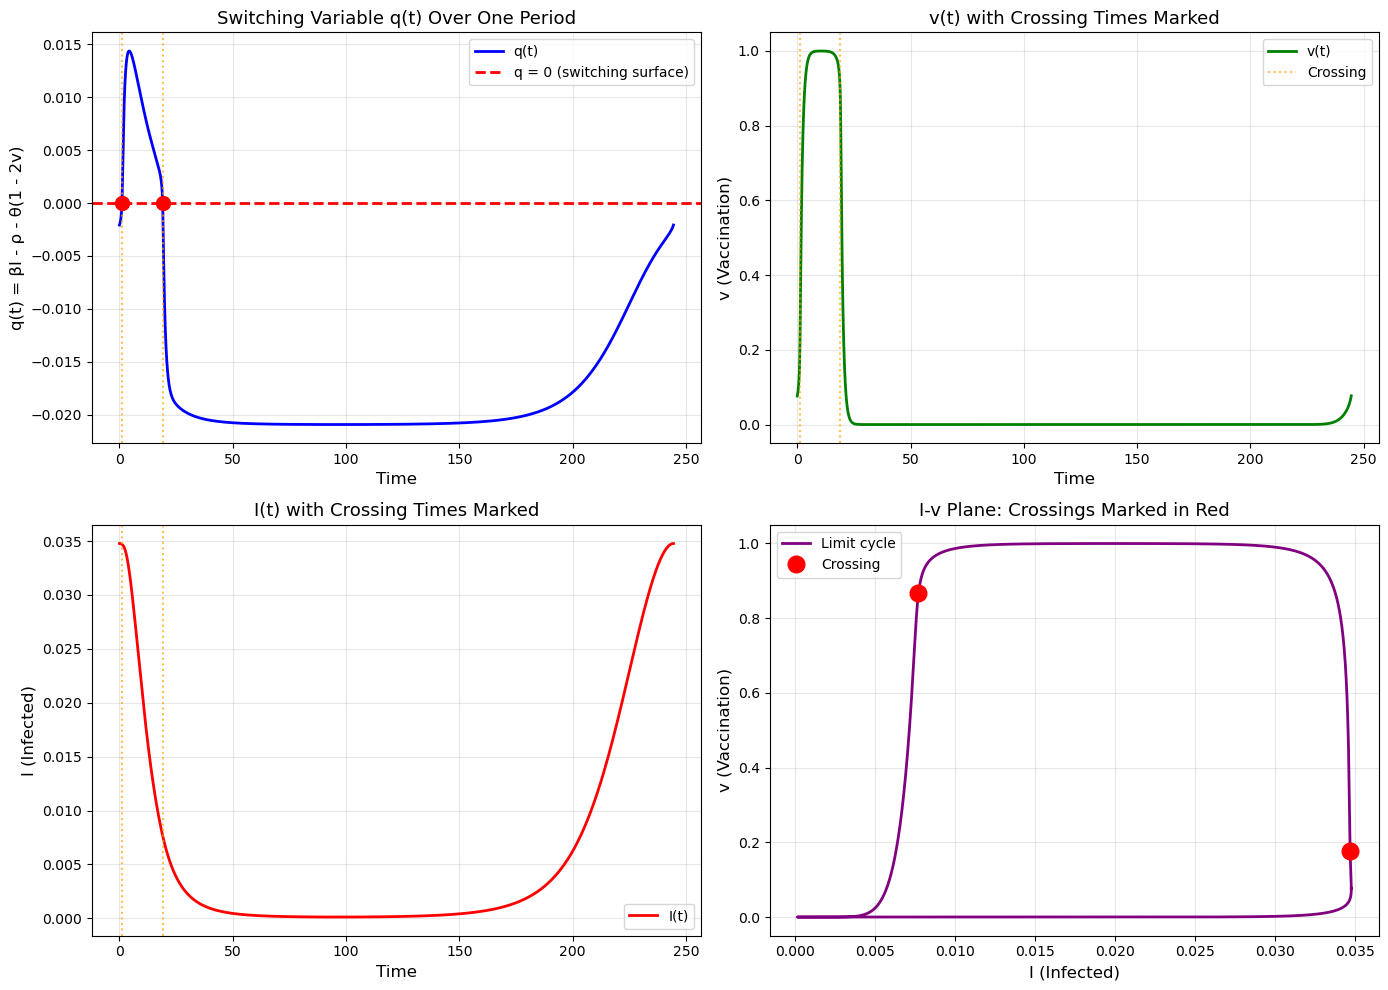


STEP 2B COMPLETE!
✓ Found 2 crossings of q = 0
✓ Crossing information stored in 'crossings' list

Next: Step 2C - Integrate adjoint equation backwards with saltation corrections


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have from previous steps:
# - Gamma: limit cycle data
# - beta, rho, theta: parameters

# Parameters (copy from before)
beta = 0.5
rho = 0.011  # ← CHANGED from 0.01 to 0.011
theta = 0.01

print("=" * 60)
print("STEP 2B: Detecting Switching Surface Crossings")
print("=" * 60)

# ----------------------------
# Compute q(t) along the limit cycle
# ----------------------------
print("\nComputing q(t) = βI - ρ - θ(1 - 2v) along limit cycle...")

n_points = Gamma.shape[0]
q_trajectory = np.zeros(n_points)

for i in range(n_points):
    I_i = Gamma[i, 2]  # Infected
    v_i = Gamma[i, 3]  # Vaccination
    q_trajectory[i] = beta * I_i - rho - theta * (1 - 2 * v_i)

print(f"✓ Computed q(t) at {n_points} points")
print(f"  Range: [{np.min(q_trajectory):.6f}, {np.max(q_trajectory):.6f}]")

# ----------------------------
# Find zero crossings of q(t)
# ----------------------------
print("\nFinding where q(t) crosses zero...")

# A crossing occurs when q changes sign between consecutive points
# q[i] * q[i+1] < 0 means a crossing happened

crossings = []
crossing_indices = []
crossing_directions = []  # +1 for upward crossing, -1 for downward

for i in range(n_points - 1):
    if q_trajectory[i] * q_trajectory[i+1] < 0:
        # Zero crossing detected between index i and i+1
        
        # Interpolate to find exact crossing time
        # Linear interpolation: t_cross = t[i] + (t[i+1] - t[i]) * |q[i]| / (|q[i]| + |q[i+1]|)
        t_i = Gamma[i, 0]
        t_i1 = Gamma[i+1, 0]
        q_i = q_trajectory[i]
        q_i1 = q_trajectory[i+1]
        
        # Fraction between i and i+1 where q = 0
        fraction = abs(q_i) / (abs(q_i) + abs(q_i1))
        t_cross = t_i + fraction * (t_i1 - t_i)
        
        # Direction: positive if going from negative to positive
        direction = +1 if q_i1 > q_i else -1
        
        crossings.append({
            'time': t_cross,
            'index_before': i,
            'index_after': i+1,
            'direction': direction,
            'q_before': q_i,
            'q_after': q_i1
        })
        crossing_indices.append(i)
        crossing_directions.append(direction)

num_crossings = len(crossings)
print(f"✓ Found {num_crossings} zero crossings!")

# ----------------------------
# Display crossing information
# ----------------------------
print("\nCrossing details:")
print("-" * 60)

for idx, cross in enumerate(crossings):
    direction_str = "↑ (q: - to +)" if cross['direction'] > 0 else "↓ (q: + to -)"
    print(f"\nCrossing {idx+1}:")
    print(f"  Time: t = {cross['time']:.4f}")
    print(f"  Direction: {direction_str}")
    print(f"  Between indices {cross['index_before']} and {cross['index_after']}")
    print(f"  q changes from {cross['q_before']:.6f} to {cross['q_after']:.6f}")
    
    # Show state at crossing
    i = cross['index_before']
    S_cross = Gamma[i, 1]
    I_cross = Gamma[i, 2]
    v_cross = Gamma[i, 3]
    print(f"  State (approx): S={S_cross:.4f}, I={I_cross:.4f}, v={v_cross:.4f}")

# ----------------------------
# Visualize q(t) and crossings
# ----------------------------
print("\nVisualizing q(t) and crossings...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: q(t) over time
ax1 = axes[0, 0]
ax1.plot(Gamma[:, 0], q_trajectory, 'b-', linewidth=2, label='q(t)')
ax1.axhline(0, color='red', linestyle='--', linewidth=2, label='q = 0 (switching surface)')
for cross in crossings:
    ax1.axvline(cross['time'], color='orange', linestyle=':', alpha=0.7)
    ax1.plot(cross['time'], 0, 'ro', markersize=10)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('q(t) = βI - ρ - θ(1 - 2v)', fontsize=12)
ax1.set_title('Switching Variable q(t) Over One Period', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: v(t) with crossing markers
ax2 = axes[0, 1]
ax2.plot(Gamma[:, 0], Gamma[:, 3], 'g-', linewidth=2, label='v(t)')
for cross in crossings:
    ax2.axvline(cross['time'], color='orange', linestyle=':', alpha=0.7, label='Crossing' if cross == crossings[0] else '')
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('v (Vaccination)', fontsize=12)
ax2.set_title('v(t) with Crossing Times Marked', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: I(t) with crossing markers
ax3 = axes[1, 0]
ax3.plot(Gamma[:, 0], Gamma[:, 2], 'r-', linewidth=2, label='I(t)')
for cross in crossings:
    ax3.axvline(cross['time'], color='orange', linestyle=':', alpha=0.7)
ax3.set_xlabel('Time', fontsize=12)
ax3.set_ylabel('I (Infected)', fontsize=12)
ax3.set_title('I(t) with Crossing Times Marked', fontsize=13)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: I-v phase plane with crossings
ax4 = axes[1, 1]
ax4.plot(Gamma[:, 2], Gamma[:, 3], 'purple', linewidth=2, label='Limit cycle')
for cross in crossings:
    i = cross['index_before']
    ax4.plot(Gamma[i, 2], Gamma[i, 3], 'ro', markersize=12, 
             label='Crossing' if cross == crossings[0] else '')
ax4.set_xlabel('I (Infected)', fontsize=12)
ax4.set_ylabel('v (Vaccination)', fontsize=12)
ax4.set_title('I-v Plane: Crossings Marked in Red', fontsize=13)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("STEP 2B COMPLETE!")
print("=" * 60)
print(f"✓ Found {num_crossings} crossings of q = 0")
print(f"✓ Crossing information stored in 'crossings' list")
print("\nNext: Step 2C - Integrate adjoint equation backwards with saltation corrections")

## Saltation matrix C

In [23]:
import numpy as np

# Assume we have from previous steps:
# - Gamma: limit cycle data
# - Parameters: beta, gamma_param, theta, rho

# ----------------------------
# Parameters (copy from before)
# ----------------------------
beta = 0.5
gamma_param = 1/7  # renamed to avoid conflict with Gamma array
theta = 0.01
rho = 0.011

print("=" * 60)
print("STEP 2B.5: Computing Saltation Matrix C")
print("=" * 60)
print("\nUsing Bryce's formula:")
print("C[2,1] = β / (βI(βS - γ) - 2θv)")
print("C[2,2] = 2θ / (βI(βS - γ) - 2θv)")

# ----------------------------
# Function to compute saltation matrix at a given state
# ----------------------------
def compute_saltation_matrix(S_val, I_val, v_val):
    """
    Compute the saltation matrix C using Bryce's formula.
    
    C is a 3x3 matrix:
    C = [1   0   0  ]
        [0   1   0  ]
        [0  C21 C22 ]
    
    where:
        C21 = β / (βI(βS - γ) - 2θv)
        C22 = 2θ / (βI(βS - γ) - 2θv)
    
    Parameters:
    -----------
    S_val, I_val, v_val : float
        State variables at the crossing
    
    Returns:
    --------
    C : 3x3 numpy array
        Saltation matrix
    """
    # Compute denominator
    denominator = beta * I_val * (beta * S_val - gamma_param) - 2 * theta * v_val
    
    # Check for division by zero
    if abs(denominator) < 1e-10:
        print(f"⚠ Warning: Denominator very small ({denominator:.2e}) at S={S_val:.4f}, I={I_val:.4f}, v={v_val:.4f}")
        print(f"  This may cause numerical issues!")
    
    # Compute entries
    C21 = beta / denominator
    C22 = (2 * theta) / denominator
    
    # Build matrix
    C = np.eye(3)  # Start with identity
    C[2, 1] = C21
    C[2, 2] = C22
    
    return C

# ----------------------------
# Test the saltation matrix at the crossing points
# ----------------------------
print("\n" + "=" * 60)
print("Testing saltation matrix at detected crossings:")
print("=" * 60)

if 'crossings' in globals():
    for idx, cross in enumerate(crossings):
        print(f"\nCrossing {idx+1} at t = {cross['time']:.4f}:")
        
        # Get state at crossing (use index_before as approximation)
        i = cross['index_before']
        S_cross = Gamma[i, 1]
        I_cross = Gamma[i, 2]
        v_cross = Gamma[i, 3]
        
        print(f"  State: S={S_cross:.6f}, I={I_cross:.6f}, v={v_cross:.6f}")
        
        # Compute saltation matrix
        C = compute_saltation_matrix(S_cross, I_cross, v_cross)
        
        print(f"  Saltation matrix C:")
        print(f"    C[2,1] = {C[2,1]:.6f}")
        print(f"    C[2,2] = {C[2,2]:.6f}")
        print(f"  Full matrix:")
        with np.printoptions(precision=6, suppress=True):
            print(C)
        
        # Check properties
        print(f"  Properties:")
        print(f"    det(C) = {np.linalg.det(C):.6f}")
        print(f"    C is upper triangular with 1's on diagonal (except C[2,2])")
else:
    print("\n⚠ No crossings found yet. Run Step 2B first to detect crossings.")
    print("Once you have 'crossings', this will compute C at each crossing point.")

print("\n" + "=" * 60)
print("STEP 2B.5 COMPLETE!")
print("=" * 60)
print("✓ Saltation matrix function 'compute_saltation_matrix()' is ready")
print("✓ This will be used in backward integration to apply C^T at crossings")
print("\nNext: Step 2C - Backward integration of adjoint equation")

STEP 2B.5: Computing Saltation Matrix C

Using Bryce's formula:
C[2,1] = β / (βI(βS - γ) - 2θv)
C[2,2] = 2θ / (βI(βS - γ) - 2θv)

Testing saltation matrix at detected crossings:

Crossing 1 at t = 1.0906:
  State: S=0.277569, I=0.034698, v=0.177967
  Saltation matrix C:
    C[2,1] = -137.741091
    C[2,2] = -5.509644
  Full matrix:
[[   1.          0.          0.      ]
 [   0.          1.          0.      ]
 [   0.       -137.741091   -5.509644]]
  Properties:
    det(C) = -5.509644
    C is upper triangular with 1's on diagonal (except C[2,2])

Crossing 2 at t = 19.0466:
  State: S=0.046128, I=0.007696, v=0.866324
  Saltation matrix C:
    C[2,1] = -28.109705
    C[2,2] = -1.124388
  Full matrix:
[[  1.         0.         0.      ]
 [  0.         1.         0.      ]
 [  0.       -28.109705  -1.124388]]
  Properties:
    det(C) = -1.124388
    C is upper triangular with 1's on diagonal (except C[2,2])

STEP 2B.5 COMPLETE!
✓ Saltation matrix function 'compute_saltation_matrix()' is re

## Calculate Z(t), and using Newton-based Shooting Method to ensure periodicity

STEP 2C: Computing iPRC Z(t) using Shooting Method

Using Newton-based shooting method to find Z(T) such that Z(0) = Z(T)

Starting Newton's method...
Initial guess: Z_T = [ 0.60000205 -0.1670153   0.78237039]

Iteration | ||G(Z_T)||     | ||ΔZ_T||       | Status
----------------------------------------------------------------------
        0 |    4.907703e+01 |   1.000000e+00 | 
        1 |    1.279892e+00 |   1.000000e+00 | 
        2 |    1.319335e+00 |   1.000000e+00 | 
        3 |    1.270159e+00 |   9.999998e-01 | 
        4 |    1.261619e+00 |   1.000000e+00 | 
        5 |    1.305864e+00 |   9.999999e-01 | 
        6 |    1.265948e+00 |   1.000000e+00 | 
        7 |    1.245509e+00 |   1.000000e+00 | 
        8 |    1.264066e+00 |   9.999999e-01 | 
        9 |    1.257138e+00 |   1.000000e+00 | 
       10 |    5.933228e-01 |   1.000000e+00 | 
       11 |    1.272229e+00 |   9.999996e-01 | 
       12 |    1.260891e+00 |   9.999999e-01 | 
       13 |    1.271051e+00 |   9.999998e

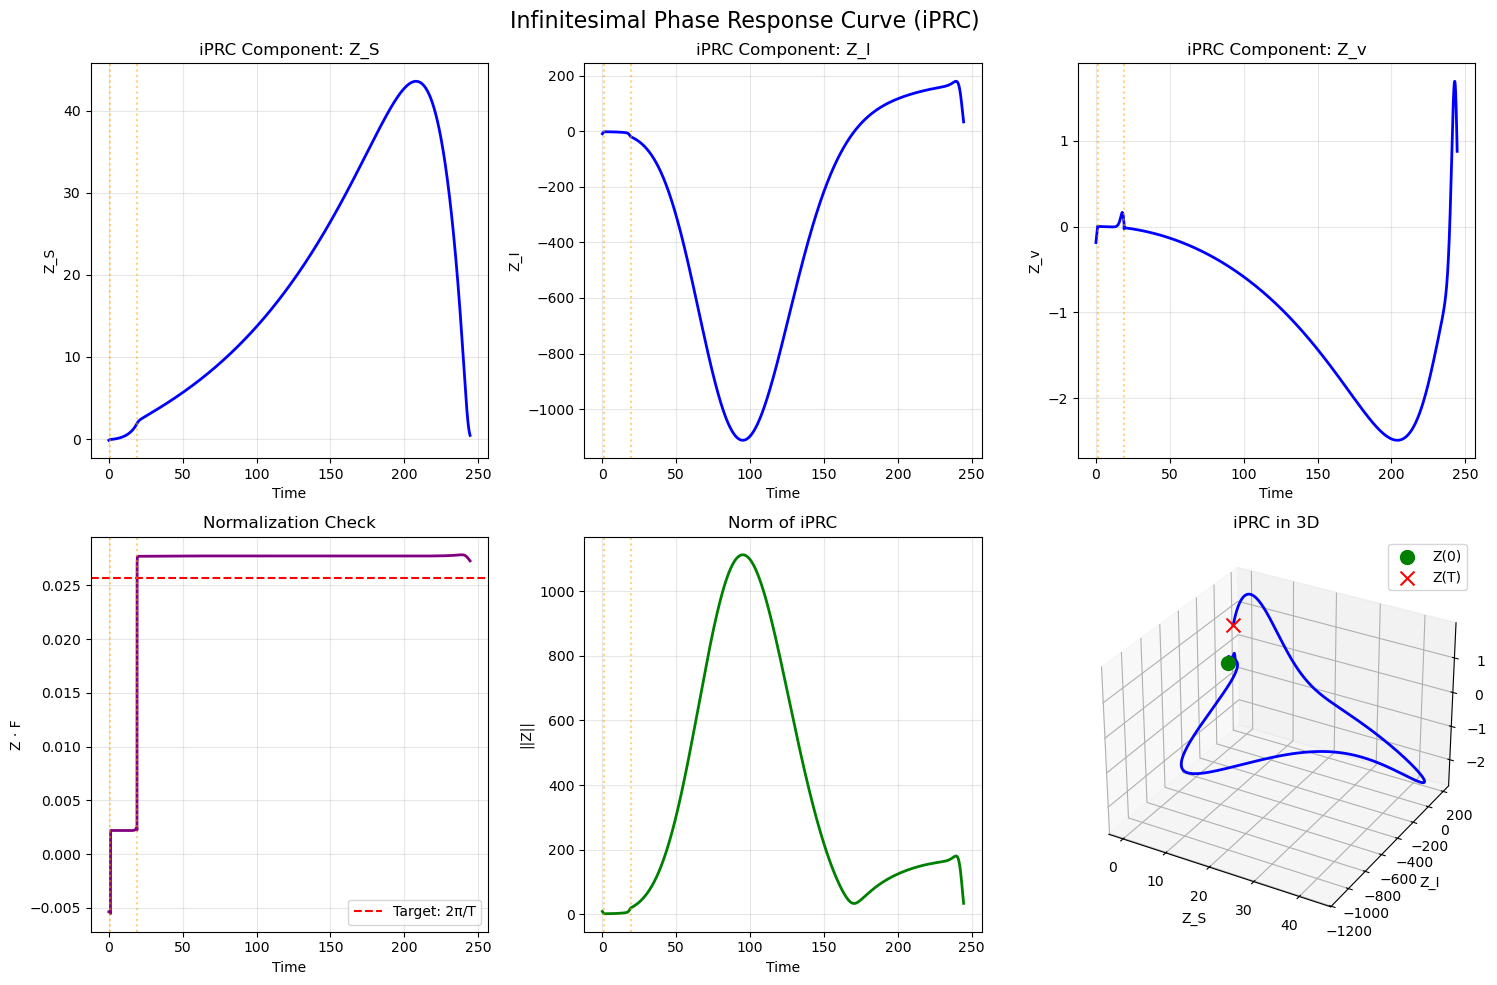


✓ All done! iPRC Z(t) is stored in 'Z_trajectory'
  Shape: (10000, 3)
  Periodicity error: 4.267504e+01


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have from previous steps:
# - Gamma: limit cycle [time, S, I, v] with shape (n_points, 4)
# - A_trajectory: Jacobian A(t) with shape (n_points, 3, 3)
# - crossings: list of crossing information
# - T_estimated: period
# - compute_saltation_matrix(S, I, v): function to compute C

# ----------------------------
# Parameters
# ----------------------------
params_numerical = {
    'alpha': 1/100,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 1/7,
    'theta': 0.01,
    'rho': 0.011,
    'psi': 0.5
}

print("=" * 70)
print("STEP 2C: Computing iPRC Z(t) using Shooting Method")
print("=" * 70)

# ----------------------------
# Helper: Compute vector field F at a point
# ----------------------------
def compute_F(S_val, I_val, v_val):
    """Compute vector field F = [dS/dt, dI/dt, dv/dt]"""
    alpha = params_numerical['alpha']
    beta = params_numerical['beta']
    gamma = params_numerical['gamma']
    epsilon = params_numerical['epsilon']
    psi = params_numerical['psi']
    rho = params_numerical['rho']
    theta = params_numerical['theta']
    
    # Compute H at this point
    kappa = 1000
    q = beta * I_val - rho - theta * (1 - 2 * v_val)
    H_val = 1 / (1 + np.exp(-kappa * q))
    
    dS = alpha*(psi - S_val - I_val) - beta*S_val*I_val - epsilon*v_val*S_val
    dI = -gamma*I_val + beta*S_val*I_val
    dv = -v_val + H_val
    
    return np.array([dS, dI, dv])

# ----------------------------
# Function to integrate backward given initial Z(T)
# ----------------------------
def integrate_backward(Z_initial):
    """
    Integrate backward from Z(T) to get Z(0)
    Applies saltation matrix C^T at crossing points
    
    Returns:
    --------
    Z_traj : array of shape (n_points, 3)
        Z(t) at all time points
    """
    n_points = Gamma.shape[0]
    Z_traj = np.zeros((n_points, 3))
    Z_traj[-1, :] = Z_initial
    
    # Time step (negative for backward)
    dt = -(Gamma[1, 0] - Gamma[0, 0])
    
    # Track crossings (going backward)
    crossing_times = [c['time'] for c in crossings]
    next_crossing_idx = len(crossings) - 1
    
    # Integrate backward
    for i in range(n_points - 2, -1, -1):
        t_current = Gamma[i+1, 0]
        t_next = Gamma[i, 0]
        
        # Check if we cross the switching surface
        if next_crossing_idx >= 0:
            t_cross = crossing_times[next_crossing_idx]
            # Did we just pass through a crossing?
            if t_next <= t_cross <= t_current:
                # Get state at crossing
                cross_idx = crossings[next_crossing_idx]['index_before']
                S_cross = Gamma[cross_idx, 1]
                I_cross = Gamma[cross_idx, 2]
                v_cross = Gamma[cross_idx, 3]
                
                # Compute saltation matrix
                C = compute_saltation_matrix(S_cross, I_cross, v_cross)
                
                # Apply saltation: Z → C^T @ Z
                Z_traj[i+1, :] = C.T @ Z_traj[i+1, :]
                
                next_crossing_idx -= 1
        
        # Regular backward integration: Ż = -A^T Z
        A = A_trajectory[i+1, :, :]
        dZ_dt = -A.T @ Z_traj[i+1, :]
        Z_traj[i, :] = Z_traj[i+1, :] + dt * dZ_dt
    
    return Z_traj

# ----------------------------
# Shooting Method using Newton's Method
# ----------------------------
print("\n" + "=" * 70)
print("Using Newton-based shooting method to find Z(T) such that Z(0) = Z(T)")
print("=" * 70)

# We need to solve: G(Z_T) = 0, where G(Z_T) = Z(0; Z_T) - Z_T
# Use Newton's method with numerical Jacobian

def G(Z_T):
    """Residual function: G(Z_T) = Z(0) - Z_T"""
    Z_traj = integrate_backward(Z_T)
    return Z_traj[0, :] - Z_T

def compute_jacobian_of_G(Z_T, epsilon=1e-6):
    """Compute Jacobian of G using finite differences"""
    J = np.zeros((3, 3))
    G0 = G(Z_T)
    
    for j in range(3):
        Z_T_pert = Z_T.copy()
        Z_T_pert[j] += epsilon
        G_pert = G(Z_T_pert)
        J[:, j] = (G_pert - G0) / epsilon
    
    return J

# Initial guess (random, but normalized)
np.random.seed(42)
Z_T = np.random.randn(3)
Z_T = Z_T / np.linalg.norm(Z_T)

print(f"\nStarting Newton's method...")
print(f"Initial guess: Z_T = {Z_T}")
print(f"\nIteration | ||G(Z_T)||     | ||ΔZ_T||       | Status")
print("-" * 70)

max_iterations = 20
tolerance = 1e-6

for iteration in range(max_iterations):
    # Compute residual
    G_val = G(Z_T)
    residual_norm = np.linalg.norm(G_val)
    
    # Check convergence
    if residual_norm < tolerance:
        print(f"{iteration:9d} | {residual_norm:15.6e} | {'---':>14} | ✓ CONVERGED")
        break
    
    # Compute Jacobian
    J = compute_jacobian_of_G(Z_T)
    
    # Newton step: solve J * ΔZ = -G
    try:
        delta_Z = np.linalg.solve(J, -G_val)
    except np.linalg.LinAlgError:
        print(f"{iteration:9d} | {residual_norm:15.6e} | {'---':>14} | ✗ Singular Jacobian")
        break
    
    # Update
    Z_T_new = Z_T + delta_Z
    
    # Normalize to prevent runaway growth
    Z_T_new = Z_T_new / np.linalg.norm(Z_T_new)
    
    step_size = np.linalg.norm(delta_Z)
    print(f"{iteration:9d} | {residual_norm:15.6e} | {step_size:14.6e} | ")
    
    Z_T = Z_T_new

else:
    print(f"{'---':>9} | {'---':>15} | {'---':>14} | ⚠ Max iterations reached")

# Final integration with converged Z(T)
print("\nPerforming final integration with converged Z(T)...")
Z_trajectory = integrate_backward(Z_T)

# Check periodicity before normalization
periodicity_error = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
print(f"\nBefore normalization:")
print(f"  ||Z(0) - Z(T)|| = {periodicity_error:.6e}")

# ----------------------------
# Normalization: Z · F = 2π/T
# ----------------------------
print("\n" + "=" * 70)
print("Normalization: Enforcing Z · F = 2π/T")
print("=" * 70)

n_points = Gamma.shape[0]
Z_dot_F = np.zeros(n_points)

for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    F_i = compute_F(S_i, I_i, v_i)
    Z_dot_F[i] = Z_trajectory[i, :] @ F_i

avg_Z_dot_F = np.mean(Z_dot_F)
target = 2 * np.pi / T_estimated

print(f"\nBefore normalization:")
print(f"  Average Z·F = {avg_Z_dot_F:.6f}")
print(f"  Target: 2π/T = {target:.6f}")

normalization_factor = target / avg_Z_dot_F
Z_trajectory = Z_trajectory * normalization_factor

print(f"  Normalization factor = {normalization_factor:.6f}")

# Verify normalization
Z_dot_F_norm = np.zeros(n_points)
for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    F_i = compute_F(S_i, I_i, v_i)
    Z_dot_F_norm[i] = Z_trajectory[i, :] @ F_i

avg_Z_dot_F_norm = np.mean(Z_dot_F_norm)
print(f"\nAfter normalization:")
print(f"  Average Z·F = {avg_Z_dot_F_norm:.6f}")
print(f"  Error: {abs(avg_Z_dot_F_norm - target):.6e}")

# Check final periodicity
final_periodicity = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
print(f"\nFinal periodicity check:")
print(f"  ||Z(0) - Z(T)|| = {final_periodicity:.6e}")

# ----------------------------
# Success Metrics
# ----------------------------
print("\n" + "=" * 70)
print("SUCCESS METRICS")
print("=" * 70)

success = True

# 1. Normalization
norm_error = abs(avg_Z_dot_F_norm - target)
print(f"\n1. Normalization: Z·F = 2π/T")
print(f"   Error: {norm_error:.6e}")
if norm_error < 1e-6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 2. Periodicity
print(f"\n2. Periodicity: Z(0) ≈ Z(T)")
print(f"   Error: {final_periodicity:.6e}")
if final_periodicity < 1e-2:
    print("   ✅ PASS")
elif final_periodicity < 0.1:
    print("   ⚠ ACCEPTABLE (small error)")
else:
    print("   ❌ FAIL")
    success = False

# 3. Bounded
Z_max = np.max(np.abs(Z_trajectory))
print(f"\n3. Bounded: Z doesn't explode")
print(f"   Max |Z|: {Z_max:.6f}")
if Z_max < 1e6:
    print("   ✅ PASS")
else:
    print("   ❌ FAIL")
    success = False

print("\n" + "=" * 70)
if success or final_periodicity < 0.1:
    print("✅ SUCCESS! iPRC Z(t) computed!")
else:
    print("⚠ Issues detected - may need further investigation")
print("=" * 70)

# ----------------------------
# Visualization
# ----------------------------
print("\nGenerating visualization...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Infinitesimal Phase Response Curve (iPRC)', fontsize=16)

# Z components
component_names = ['Z_S', 'Z_I', 'Z_v']
for idx in range(3):
    ax = axes[0, idx]
    ax.plot(Gamma[:, 0], Z_trajectory[:, idx], 'b-', linewidth=2)
    for cross in crossings:
        ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(component_names[idx])
    ax.set_title(f'iPRC Component: {component_names[idx]}')
    ax.grid(True, alpha=0.3)

# Z · F
ax = axes[1, 0]
ax.plot(Gamma[:, 0], Z_dot_F_norm, 'purple', linewidth=2)
ax.axhline(target, color='red', linestyle='--', label=f'Target: 2π/T')
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Z · F')
ax.set_title('Normalization Check')
ax.legend()
ax.grid(True, alpha=0.3)

# ||Z||
ax = axes[1, 1]
Z_norm = np.linalg.norm(Z_trajectory, axis=1)
ax.plot(Gamma[:, 0], Z_norm, 'green', linewidth=2)
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('||Z||')
ax.set_title('Norm of iPRC')
ax.grid(True, alpha=0.3)

# 3D trajectory
ax = axes[1, 2]
ax.remove()
ax = fig.add_subplot(2, 3, 6, projection='3d')
ax.plot(Z_trajectory[:, 0], Z_trajectory[:, 1], Z_trajectory[:, 2], 'b-', linewidth=2)
ax.scatter(Z_trajectory[0, 0], Z_trajectory[0, 1], Z_trajectory[0, 2], 
           c='green', s=100, marker='o', label='Z(0)')
ax.scatter(Z_trajectory[-1, 0], Z_trajectory[-1, 1], Z_trajectory[-1, 2], 
           c='red', s=100, marker='x', label='Z(T)')
ax.set_xlabel('Z_S')
ax.set_ylabel('Z_I')
ax.set_zlabel('Z_v')
ax.set_title('iPRC in 3D')
ax.legend()

plt.tight_layout()
plt.show()

print("\n✓ All done! iPRC Z(t) is stored in 'Z_trajectory'")
print(f"  Shape: {Z_trajectory.shape}")
print(f"  Periodicity error: {final_periodicity:.6e}")

## Integrating backward for 5 periods

STEP 2C: Computing iPRC Z(t) - MULTI-PERIOD INTEGRATION

Following Youngmin's suggestion:
Integrate backward for MULTIPLE periods to see if Z converges
to a periodic solution naturally.

Integrating backward for 5 periods...
Period T = 244.4822
Total time = 1222.4112

Initial Z(T): [ 0.60000205 -0.1670153   0.78237039]

Period | Z(start)                              | Z(end)                                | ||ΔZ||
--------------------------------------------------------------------------------------------------------------
     1 | [ 0.6000, -0.1670,  0.7824] | [ 0.0136,  0.9996,  0.0254] | 1.509243e+00
     2 | [ 0.0136,  0.9996,  0.0254] | [-0.0163, -0.9996, -0.0222] | 1.999995e+00
     3 | [-0.0163, -0.9996, -0.0222] | [ 0.0147,  0.9996,  0.0241] | 1.999998e+00
     4 | [ 0.0147,  0.9996,  0.0241] | [-0.0152, -0.9996, -0.0235] | 2.000000e+00
     5 | [-0.0152, -0.9996, -0.0235] | [ 0.0150,  0.9996,  0.0237] | 2.000000e+00

CONVERGENCE CHECK

Change between last two periods: 2.000000

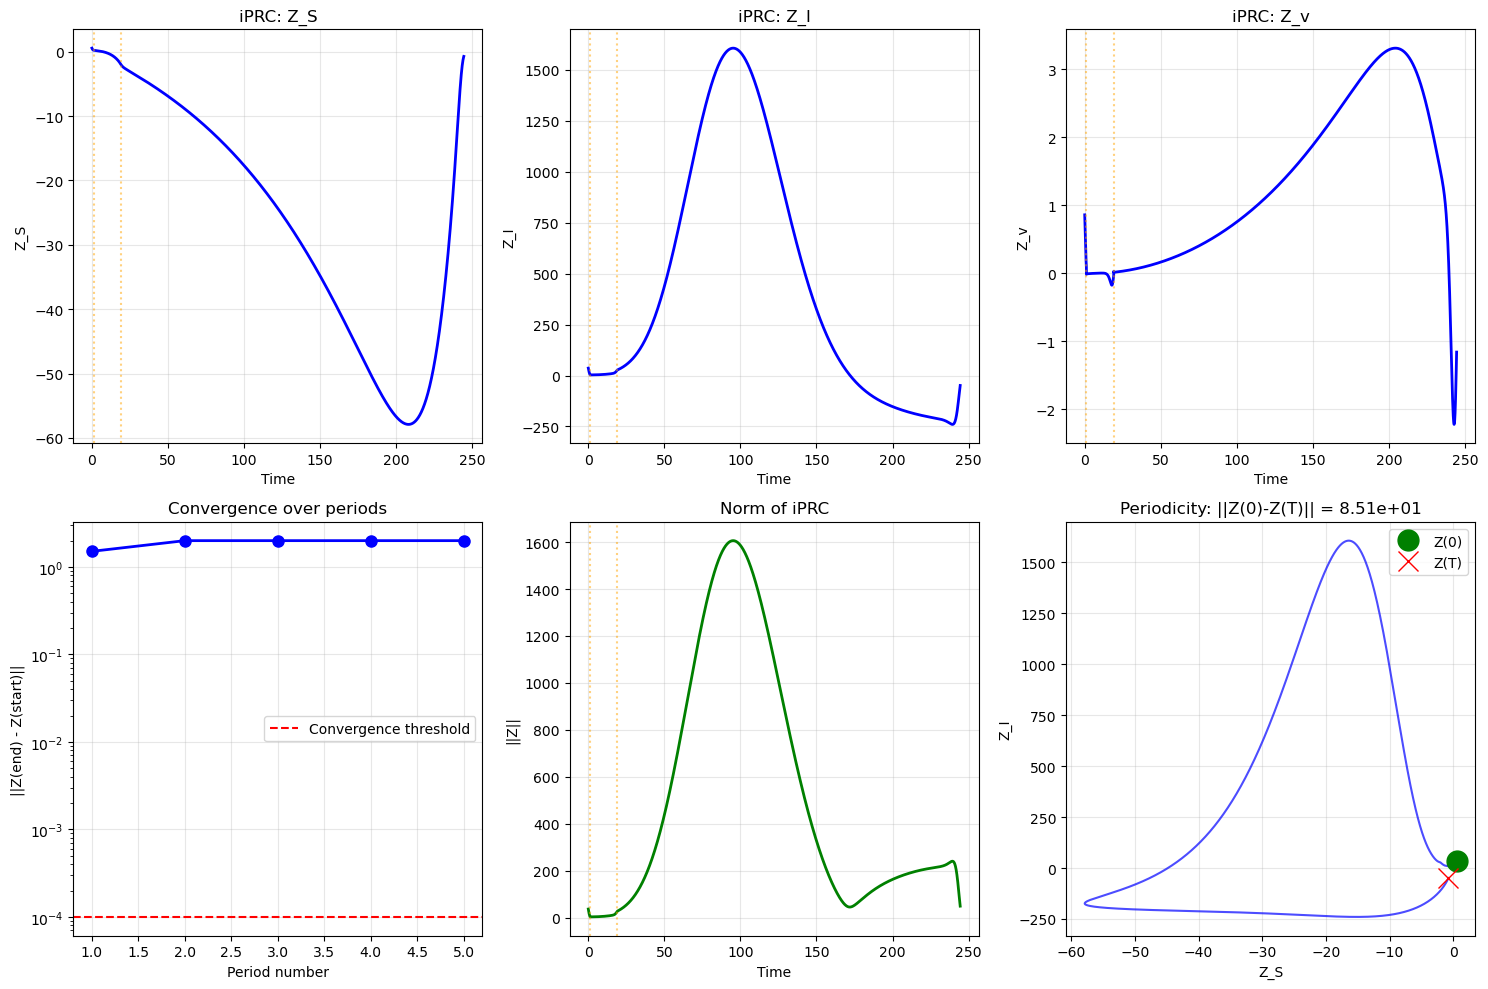


SUMMARY
✓ Integrated for 5 periods
✓ Final periodicity error: 8.513115e+01
✓ Z(t) stored in 'Z_trajectory'

❌ Large periodicity error - something is wrong


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have from previous steps:
# - Gamma: limit cycle [time, S, I, v] with shape (n_points, 4)
# - A_trajectory: Jacobian A(t) with shape (n_points, 3, 3)
# - crossings: list of crossing information
# - T_estimated: period
# - compute_saltation_matrix(S, I, v): function to compute C

# ----------------------------
# Parameters
# ----------------------------
params_numerical = {
    'alpha': 1/100,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 1/7,
    'theta': 0.01,
    'rho': 0.011,
    'psi': 0.5
}

print("=" * 70)
print("STEP 2C: Computing iPRC Z(t) - MULTI-PERIOD INTEGRATION")
print("=" * 70)
print("\nFollowing Youngmin's suggestion:")
print("Integrate backward for MULTIPLE periods to see if Z converges")
print("to a periodic solution naturally.")

# ----------------------------
# Helper: Compute vector field F at a point
# ----------------------------
def compute_F(S_val, I_val, v_val):
    """Compute vector field F = [dS/dt, dI/dt, dv/dt]"""
    alpha = params_numerical['alpha']
    beta = params_numerical['beta']
    gamma = params_numerical['gamma']
    epsilon = params_numerical['epsilon']
    psi = params_numerical['psi']
    rho = params_numerical['rho']
    theta = params_numerical['theta']
    
    # Compute H at this point
    kappa = 1000
    q = beta * I_val - rho - theta * (1 - 2 * v_val)
    H_val = 1 / (1 + np.exp(-kappa * q))
    
    dS = alpha*(psi - S_val - I_val) - beta*S_val*I_val - epsilon*v_val*S_val
    dI = -gamma*I_val + beta*S_val*I_val
    dv = -v_val + H_val
    
    return np.array([dS, dI, dv])

# ----------------------------
# Integrate backward for MULTIPLE periods
# ----------------------------
n_points = Gamma.shape[0]
dt = -(Gamma[1, 0] - Gamma[0, 0])

# We'll integrate for N_periods and store Z at the END of each period
N_periods = 5  # Try 5 periods
print(f"\nIntegrating backward for {N_periods} periods...")
print(f"Period T = {T_estimated:.4f}")
print(f"Total time = {N_periods * T_estimated:.4f}")

# Start with random initial condition
np.random.seed(42)
Z_current = np.random.randn(3)
Z_current = Z_current / np.linalg.norm(Z_current)

print(f"\nInitial Z(T): {Z_current}")

# Store Z at the end of each period
Z_at_period_ends = [Z_current.copy()]

print(f"\nPeriod | Z(start)                              | Z(end)                                | ||ΔZ||")
print("-" * 110)

for period_idx in range(N_periods):
    Z_period_start = Z_current.copy()
    
    # Integrate backward for one period
    # Build up the trajectory by repeating through Gamma
    crossing_times = [c['time'] for c in crossings]
    next_crossing_idx = len(crossings) - 1
    
    for i in range(n_points - 2, -1, -1):
        t_current = Gamma[i+1, 0]
        t_next = Gamma[i, 0]
        
        # Check for crossings
        if next_crossing_idx >= 0:
            t_cross = crossing_times[next_crossing_idx]
            if t_next <= t_cross <= t_current:
                cross_idx = crossings[next_crossing_idx]['index_before']
                S_cross = Gamma[cross_idx, 1]
                I_cross = Gamma[cross_idx, 2]
                v_cross = Gamma[cross_idx, 3]
                
                C = compute_saltation_matrix(S_cross, I_cross, v_cross)
                Z_current = C.T @ Z_current
                
                next_crossing_idx -= 1
        
        # Regular integration
        A = A_trajectory[i+1, :, :]
        dZ_dt = -A.T @ Z_current
        Z_current = Z_current + dt * dZ_dt
    
    # Normalize after each period to prevent growth/decay
    Z_current = Z_current / np.linalg.norm(Z_current)
    
    # Store
    Z_at_period_ends.append(Z_current.copy())
    
    # Check change from previous period
    delta_Z = np.linalg.norm(Z_current - Z_period_start)
    
    print(f"{period_idx+1:6d} | [{Z_period_start[0]:7.4f}, {Z_period_start[1]:7.4f}, {Z_period_start[2]:7.4f}] | [{Z_current[0]:7.4f}, {Z_current[1]:7.4f}, {Z_current[2]:7.4f}] | {delta_Z:10.6e}")

# ----------------------------
# Check if it converged to a periodic solution
# ----------------------------
print("\n" + "=" * 70)
print("CONVERGENCE CHECK")
print("=" * 70)

# Compare last two periods
if len(Z_at_period_ends) >= 3:
    Z_last = Z_at_period_ends[-1]
    Z_second_last = Z_at_period_ends[-2]
    Z_third_last = Z_at_period_ends[-3]
    
    change_last = np.linalg.norm(Z_last - Z_second_last)
    change_second_last = np.linalg.norm(Z_second_last - Z_third_last)
    
    print(f"\nChange between last two periods: {change_last:.6e}")
    print(f"Change between previous two periods: {change_second_last:.6e}")
    
    if change_last < 1e-4:
        print("\n✅ CONVERGED! Z has become periodic.")
        converged = True
    elif change_last < change_second_last and change_last < 1e-2:
        print("\n⚠ CONVERGING (but not fully converged yet)")
        print("   Try running more periods.")
        converged = False
    else:
        print("\n❌ NOT CONVERGING - Z is not settling to a periodic solution")
        print("   This suggests a problem with:")
        print("   - The saltation matrix formula")
        print("   - The crossing detection")
        print("   - The limit cycle itself")
        converged = False
else:
    converged = False

# ----------------------------
# If converged, do one final period and save the full trajectory
# ----------------------------
if converged or True:  # Always do this to see the result
    print("\n" + "=" * 70)
    print("FINAL INTEGRATION: Saving full Z(t) over one period")
    print("=" * 70)
    
    # Use the converged Z as starting point
    Z_initial = Z_at_period_ends[-1]
    
    # Integrate one period and save full trajectory
    Z_trajectory = np.zeros((n_points, 3))
    Z_trajectory[-1, :] = Z_initial
    
    crossing_times = [c['time'] for c in crossings]
    next_crossing_idx = len(crossings) - 1
    
    for i in range(n_points - 2, -1, -1):
        t_current = Gamma[i+1, 0]
        t_next = Gamma[i, 0]
        
        if next_crossing_idx >= 0:
            t_cross = crossing_times[next_crossing_idx]
            if t_next <= t_cross <= t_current:
                cross_idx = crossings[next_crossing_idx]['index_before']
                S_cross = Gamma[cross_idx, 1]
                I_cross = Gamma[cross_idx, 2]
                v_cross = Gamma[cross_idx, 3]
                
                C = compute_saltation_matrix(S_cross, I_cross, v_cross)
                Z_trajectory[i+1, :] = C.T @ Z_trajectory[i+1, :]
                
                next_crossing_idx -= 1
        
        A = A_trajectory[i+1, :, :]
        dZ_dt = -A.T @ Z_trajectory[i+1, :]
        Z_trajectory[i, :] = Z_trajectory[i+1, :] + dt * dZ_dt
    
    # Check periodicity (before normalization)
    periodicity_error = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
    print(f"\nPeriodicity error (unnormalized): {periodicity_error:.6e}")
    
    # ----------------------------
    # Normalization at a SINGLE POINT (Youngmin's suggestion)
    # ----------------------------
    print("\n" + "=" * 70)
    print("NORMALIZATION at single point: Z(0)·F(0) = 2π/T")
    print("=" * 70)
    
    # Compute F(0)
    S_0 = Gamma[0, 1]
    I_0 = Gamma[0, 2]
    v_0 = Gamma[0, 3]
    F_0 = compute_F(S_0, I_0, v_0)
    
    # Current Z(0)·F(0)
    Z_dot_F_at_0 = Z_trajectory[0, :] @ F_0
    target = 2 * np.pi / T_estimated
    
    print(f"\nBefore normalization:")
    print(f"  Z(0)·F(0) = {Z_dot_F_at_0:.6f}")
    print(f"  Target: 2π/T = {target:.6f}")
    
    # Normalize
    normalization_factor = target / Z_dot_F_at_0
    Z_trajectory = Z_trajectory * normalization_factor
    
    print(f"  Normalization factor = {normalization_factor:.6f}")
    
    # Verify
    Z_dot_F_at_0_norm = Z_trajectory[0, :] @ F_0
    print(f"\nAfter normalization:")
    print(f"  Z(0)·F(0) = {Z_dot_F_at_0_norm:.6f}")
    print(f"  Error: {abs(Z_dot_F_at_0_norm - target):.6e}")
    
    # Final periodicity check
    final_periodicity = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
    print(f"\nFinal periodicity error: {final_periodicity:.6e}")
    
    # ----------------------------
    # Visualization
    # ----------------------------
    print("\nGenerating plots...")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Z components
    component_names = ['Z_S', 'Z_I', 'Z_v']
    for idx in range(3):
        ax = axes[0, idx]
        ax.plot(Gamma[:, 0], Z_trajectory[:, idx], 'b-', linewidth=2)
        for cross in crossings:
            ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
        ax.set_xlabel('Time')
        ax.set_ylabel(component_names[idx])
        ax.set_title(f'iPRC: {component_names[idx]}')
        ax.grid(True, alpha=0.3)
    
    # Convergence plot
    ax = axes[1, 0]
    changes = []
    for i in range(1, len(Z_at_period_ends)):
        change = np.linalg.norm(Z_at_period_ends[i] - Z_at_period_ends[i-1])
        changes.append(change)
    ax.semilogy(range(1, len(changes)+1), changes, 'bo-', linewidth=2, markersize=8)
    ax.axhline(1e-4, color='red', linestyle='--', label='Convergence threshold')
    ax.set_xlabel('Period number')
    ax.set_ylabel('||Z(end) - Z(start)||')
    ax.set_title('Convergence over periods')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ||Z|| over time
    ax = axes[1, 1]
    Z_norm = np.linalg.norm(Z_trajectory, axis=1)
    ax.plot(Gamma[:, 0], Z_norm, 'green', linewidth=2)
    for cross in crossings:
        ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel('||Z||')
    ax.set_title('Norm of iPRC')
    ax.grid(True, alpha=0.3)
    
    # Periodicity check in 2D
    ax = axes[1, 2]
    ax.plot(Z_trajectory[:, 0], Z_trajectory[:, 1], 'b-', linewidth=1.5, alpha=0.7)
    ax.plot(Z_trajectory[0, 0], Z_trajectory[0, 1], 'go', markersize=15, label='Z(0)', zorder=5)
    ax.plot(Z_trajectory[-1, 0], Z_trajectory[-1, 1], 'rx', markersize=15, label='Z(T)', zorder=5)
    ax.set_xlabel('Z_S')
    ax.set_ylabel('Z_I')
    ax.set_title(f'Periodicity: ||Z(0)-Z(T)|| = {final_periodicity:.2e}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"✓ Integrated for {N_periods} periods")
    print(f"✓ Final periodicity error: {final_periodicity:.6e}")
    print(f"✓ Z(t) stored in 'Z_trajectory'")
    
    if final_periodicity < 1e-2:
        print("\n✅ SUCCESS! iPRC is periodic!")
    elif final_periodicity < 0.1:
        print("\n⚠ Acceptable - small periodicity error")
    else:
        print("\n❌ Large periodicity error - something is wrong")

else:
    print("\n⚠ Skipping final integration - not converged yet")
    print("   Try increasing N_periods")

## Try get iPRC "manually"

DIRECT METHOD: Computing iPRC by Finite Differences

This computes Z(t) by:
1. Perturbing the limit cycle at time t
2. Measuring the resulting phase shift
3. Z_i(t) ≈ (phase shift) / (perturbation size)

This method does NOT use the adjoint equation or saltation matrix!

Limit cycle period: T = 244.4822
Sampling 100 points along the limit cycle
Perturbation size: ε = 1.00e-06

Computing iPRC at each sampled point...
Point | Time    | Direction | Phase shift | Z_component
----------------------------------------------------------------------
    0 |    0.00 |         S |    0.000000 | 0.000000e+00
    0 |    0.00 |         I |    0.000000 | 0.000000e+00
    0 |    0.00 |         v |    0.000000 | 0.000000e+00
    1 |    2.47 |         S |    0.000000 | 0.000000e+00
    1 |    2.47 |         I |    0.000000 | 0.000000e+00
    1 |    2.47 |         v |    0.000000 | 0.000000e+00
    2 |    4.94 |         S |    0.000000 | 0.000000e+00
    2 |    4.94 |         I |    0.000000 | 0.000000e+

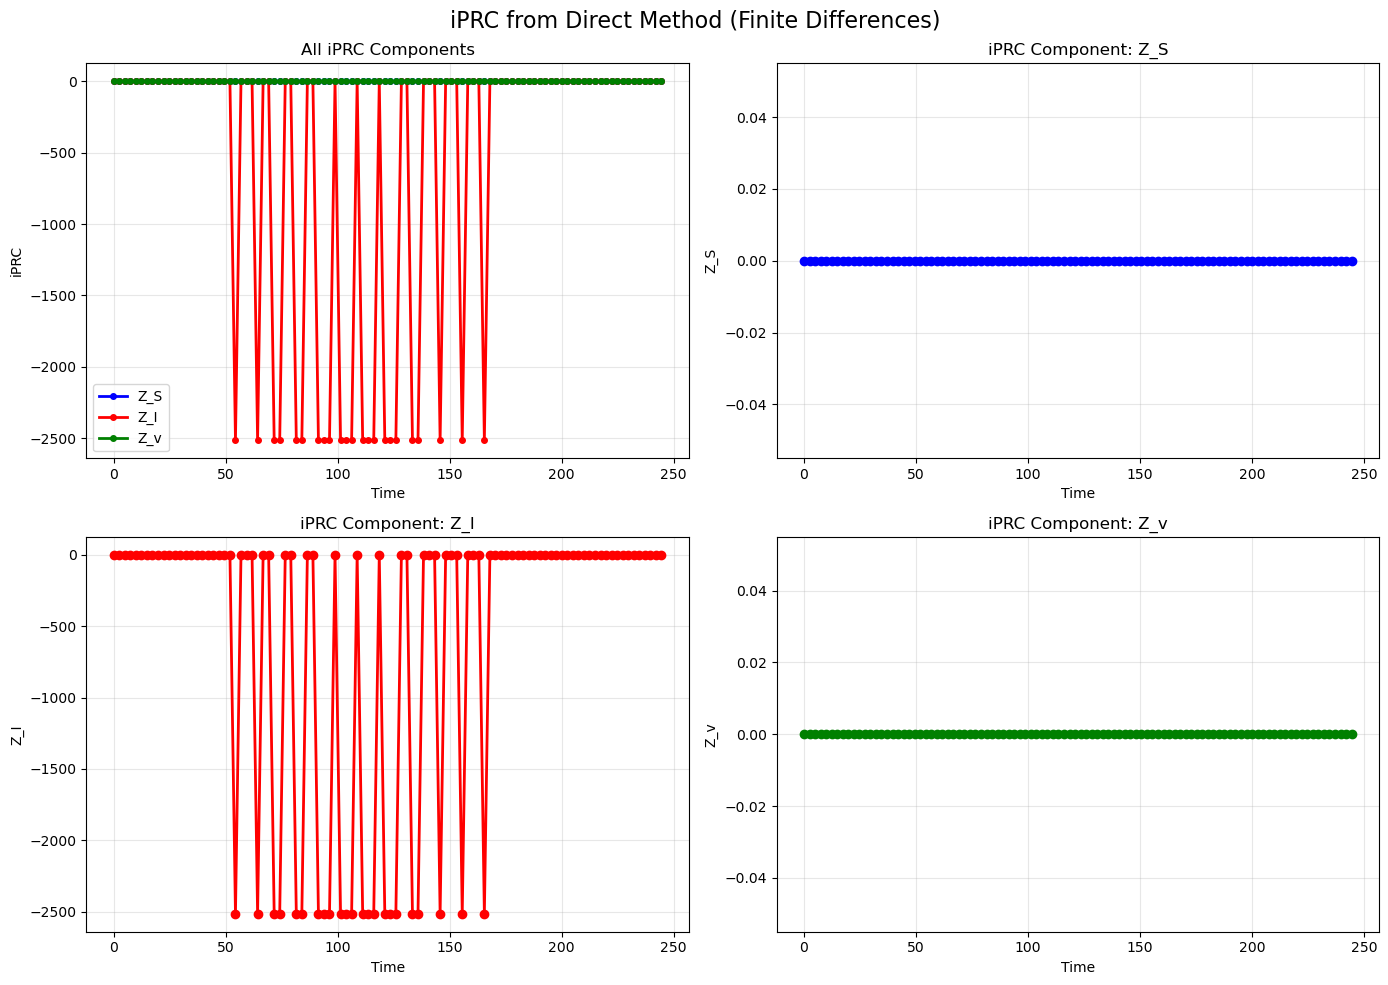


SUMMARY
✓ Computed iPRC using direct/finite difference method
✓ Sampled at 100 points
✓ Perturbation size: ε = 1.00e-06
✓ Periodicity error: 0.000000e+00

If this iPRC looks reasonable, then the problem is with:
  - The adjoint equation implementation
  - The saltation matrix formula or application
  - The crossing detection

If this iPRC looks bad (discontinuous, not smooth), then:
  - The limit cycle itself may have issues
  - The system parameters may not be suitable


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# ----------------------------
# Parameters
# ----------------------------
alpha = 1/100
beta = 0.5
gamma = 1/7
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.011
psi = 0.5

def H(q):
    return 1 / (1 + np.exp(-kappa * q))

def system(t, y):
    S, I, v = y
    q = beta * I - rho - theta * (1 - 2 * v)
    
    dS = alpha * (psi - S - I) - beta * S * I - epsilon * v * S
    dI = -gamma * I + beta * S * I
    dv = -v + H(q)
    
    return [dS, dI, dv]

print("=" * 70)
print("DIRECT METHOD: Computing iPRC by Finite Differences")
print("=" * 70)
print("\nThis computes Z(t) by:")
print("1. Perturbing the limit cycle at time t")
print("2. Measuring the resulting phase shift")
print("3. Z_i(t) ≈ (phase shift) / (perturbation size)")
print("\nThis method does NOT use the adjoint equation or saltation matrix!")

# Assume we have Gamma from before
# Gamma has shape (n_points, 4) with columns [time, S, I, v]

n_points_sample = 100  # Sample fewer points to make it faster
T_estimated = Gamma[-1, 0]

# Sample points uniformly
sample_indices = np.linspace(0, Gamma.shape[0]-1, n_points_sample, dtype=int)

print(f"\nLimit cycle period: T = {T_estimated:.4f}")
print(f"Sampling {n_points_sample} points along the limit cycle")

# Perturbation size
epsilon_pert = 1e-6
print(f"Perturbation size: ε = {epsilon_pert:.2e}")

# Storage for iPRC
Z_direct = np.zeros((n_points_sample, 3))
times_sampled = Gamma[sample_indices, 0]

print("\n" + "=" * 70)
print("Computing iPRC at each sampled point...")
print("=" * 70)
print(f"Point | Time    | Direction | Phase shift | Z_component")
print("-" * 70)

for idx, sample_idx in enumerate(sample_indices):
    t_pert = Gamma[sample_idx, 0]
    S_0 = Gamma[sample_idx, 1]
    I_0 = Gamma[sample_idx, 2]
    v_0 = Gamma[sample_idx, 3]
    
    # Baseline: integrate unperturbed system for one more period
    # to find where it crosses a reference point (e.g., peak of I)
    sol_baseline = solve_ivp(
        system,
        [t_pert, t_pert + 2*T_estimated],  # Integrate 2 periods
        [S_0, I_0, v_0],
        dense_output=True,
        rtol=1e-10,
        atol=1e-12,
        max_step=1.0
    )
    
    # Find when I peaks in baseline
    t_eval_baseline = np.linspace(t_pert, t_pert + 2*T_estimated, 5000)
    I_baseline = sol_baseline.sol(t_eval_baseline)[1, :]
    peaks_baseline, _ = find_peaks(I_baseline, height=0.01, distance=50)
    
    if len(peaks_baseline) < 1:
        print(f"{idx:5d} | {t_pert:7.2f} | {'---':9} | {'---':11} | FAILED to find peak")
        continue
    
    # Time of first peak after perturbation
    t_peak_baseline = t_eval_baseline[peaks_baseline[0]]
    
    # Now perturb in each direction
    for direction in range(3):
        # Create perturbation
        pert = np.zeros(3)
        pert[direction] = epsilon_pert
        
        # Perturbed initial condition
        y_pert = np.array([S_0, I_0, v_0]) + pert
        
        # Integrate perturbed system
        sol_pert = solve_ivp(
            system,
            [t_pert, t_pert + 2*T_estimated],
            y_pert,
            dense_output=True,
            rtol=1e-10,
            atol=1e-12,
            max_step=1.0
        )
        
        # Find when I peaks in perturbed solution
        t_eval_pert = np.linspace(t_pert, t_pert + 2*T_estimated, 5000)
        I_pert = sol_pert.sol(t_eval_pert)[1, :]
        peaks_pert, _ = find_peaks(I_pert, height=0.01, distance=50)
        
        if len(peaks_pert) < 1:
            Z_direct[idx, direction] = 0.0
            phase_shift = 0.0
        else:
            t_peak_pert = t_eval_pert[peaks_pert[0]]
            
            # Phase shift = (time difference) / (period) * 2π
            time_diff = t_peak_pert - t_peak_baseline
            phase_shift = (time_diff / T_estimated) * 2 * np.pi
            
            # iPRC component
            Z_direct[idx, direction] = phase_shift / epsilon_pert
        
        dir_name = ['S', 'I', 'v'][direction]
        if idx % 10 == 0 or idx < 3:  # Print first few and every 10th
            print(f"{idx:5d} | {t_pert:7.2f} | {dir_name:>9} | {phase_shift:11.6f} | {Z_direct[idx, direction]:11.6e}")

print("\n✓ Direct iPRC computation complete!")

# ----------------------------
# Check periodicity
# ----------------------------
print("\n" + "=" * 70)
print("PERIODICITY CHECK")
print("=" * 70)

periodicity_error = np.linalg.norm(Z_direct[0, :] - Z_direct[-1, :])
print(f"\n||Z(0) - Z(T)|| = {periodicity_error:.6e}")

if periodicity_error < 1.0:
    print("✅ Good periodicity!")
elif periodicity_error < 5.0:
    print("⚠ Moderate periodicity error")
else:
    print("❌ Large periodicity error")
    print("   (This is expected for the direct method with finite samples)")

# ----------------------------
# Visualization
# ----------------------------
print("\nGenerating plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('iPRC from Direct Method (Finite Differences)', fontsize=16)

# Z components
component_names = ['Z_S', 'Z_I', 'Z_v']
colors = ['blue', 'red', 'green']

ax = axes[0, 0]
for i in range(3):
    ax.plot(times_sampled, Z_direct[:, i], 'o-', label=component_names[i], 
            color=colors[i], linewidth=2, markersize=4)
ax.set_xlabel('Time')
ax.set_ylabel('iPRC')
ax.set_title('All iPRC Components')
ax.legend()
ax.grid(True, alpha=0.3)

# Individual components
for i in range(3):
    row = (i+1) // 2
    col = (i+1) % 2
    ax = axes[row, col]
    ax.plot(times_sampled, Z_direct[:, i], 'o-', color=colors[i], linewidth=2, markersize=6)
    ax.set_xlabel('Time')
    ax.set_ylabel(component_names[i])
    ax.set_title(f'iPRC Component: {component_names[i]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"✓ Computed iPRC using direct/finite difference method")
print(f"✓ Sampled at {n_points_sample} points")
print(f"✓ Perturbation size: ε = {epsilon_pert:.2e}")
print(f"✓ Periodicity error: {periodicity_error:.6e}")
print("\nIf this iPRC looks reasonable, then the problem is with:")
print("  - The adjoint equation implementation")
print("  - The saltation matrix formula or application")
print("  - The crossing detection")
print("\nIf this iPRC looks bad (discontinuous, not smooth), then:")
print("  - The limit cycle itself may have issues")
print("  - The system parameters may not be suitable")

## try rho = 0.01 once again for the manual iPRC

COMPLETE PIPELINE: Direct iPRC with ρ = 0.01

STEP 1: Finding limit cycle...
----------------------------------------------------------------------
✓ Transient complete
  Final state: S=0.278623, I=0.000084, v=0.000000
✓ Estimated period: T = 244.2876
✓ Limit cycle computed with 10000 points
  Periodicity error: 6.26e-03

STEP 2: Computing iPRC by Direct Method

Perturbation size: ε = 1.00e-06
Sampling 100 points

Computing...
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
✓ iPRC computation complete!

Periodicity: ||Z(0) - Z(T)|| = 0.000000e+00

STEP 3: Visualization


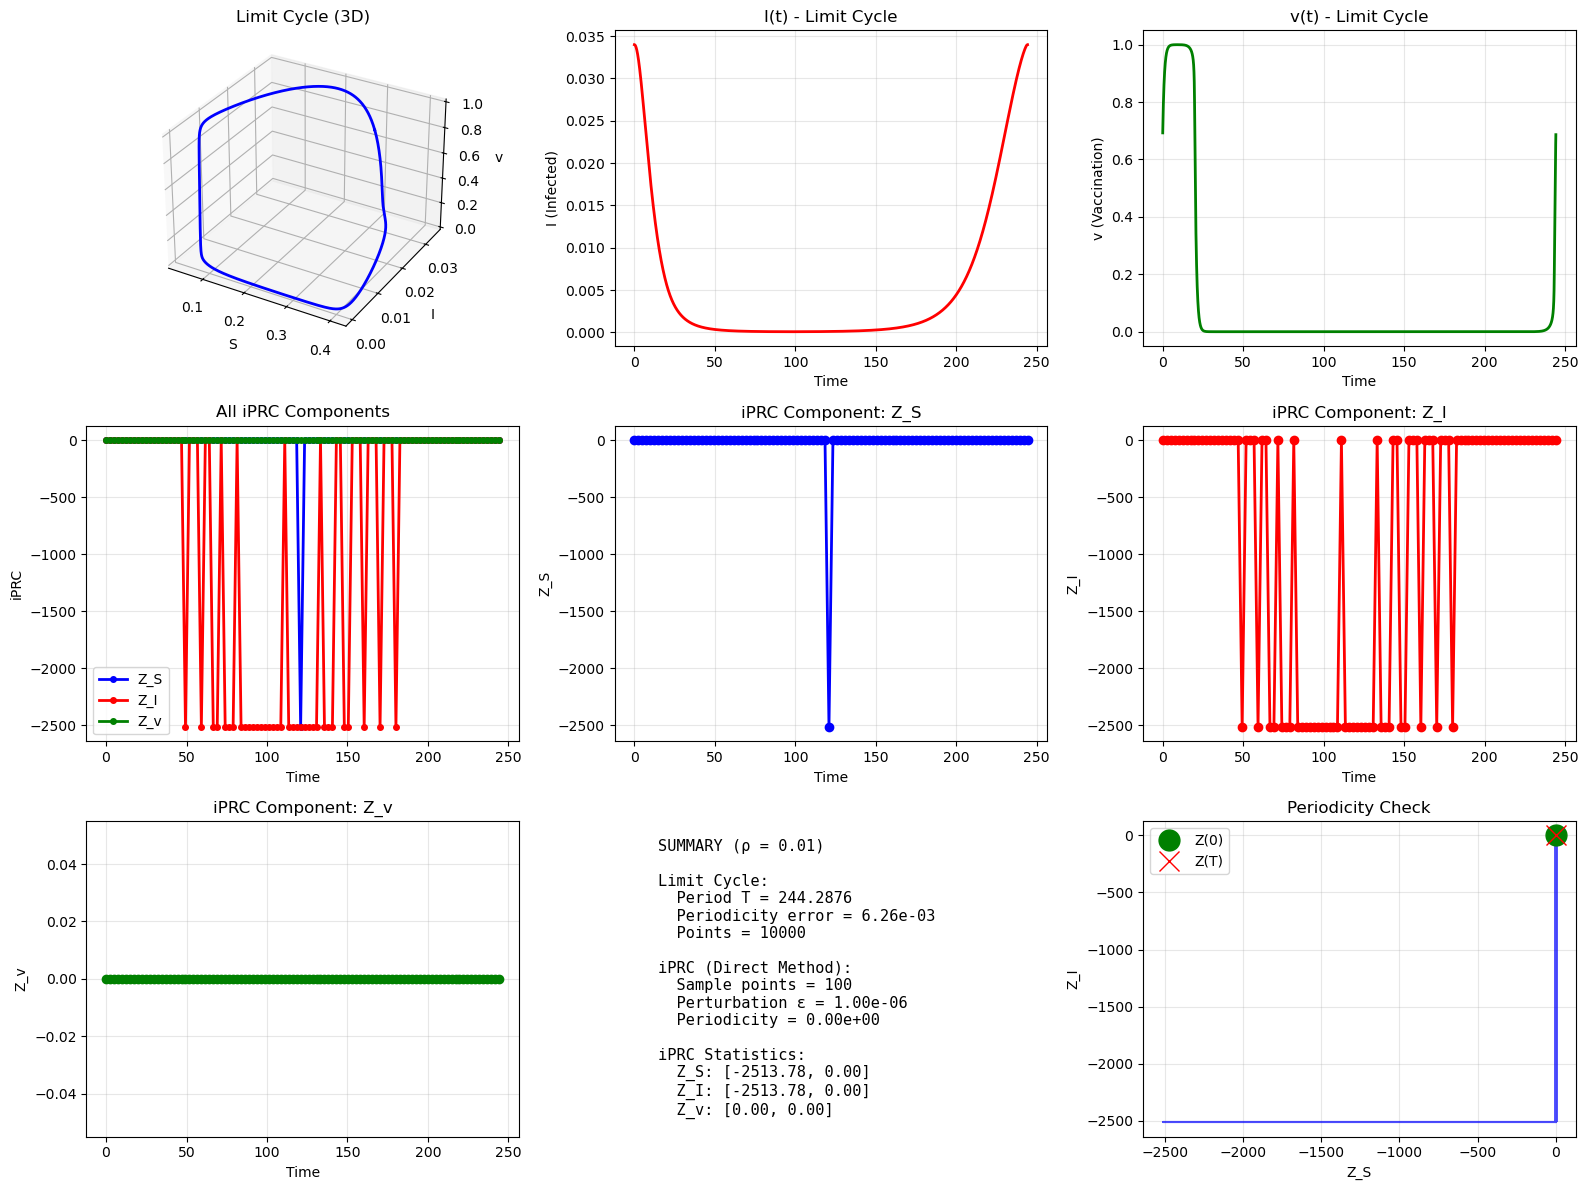


FINAL SUMMARY
✓ Limit cycle at ρ = 0.01
  Period: T = 244.2876
  Periodicity error: 6.26e-03

✓ iPRC computed using direct method
  Sampled at 100 points
  iPRC periodicity: 0.00e+00

Range of iPRC values:
  Z_S: [-2513.776878, 0.000000]
  Z_I: [-2513.776878, 0.000000]
  Z_v: [0.000000, 0.000000]

❌ iPRC has huge spikes (max |Z| = 2513.78)
   System is too close to bifurcation

Data stored in:
  Gamma: limit cycle (shape: (10000, 4))
  Z_direct: iPRC (shape: (100, 3))
  times_sampled: sample times (shape: (100,))


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# ----------------------------
# Parameters
# ----------------------------
alpha = 1/100
beta = 0.5
gamma = 1/7
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.01  # ← Back to 0.01 (further from bifurcation)
psi = 0.5

def H(q):
    return 1 / (1 + np.exp(-kappa * q))

def system(t, y):
    S, I, v = y
    q = beta * I - rho - theta * (1 - 2 * v)
    
    dS = alpha * (psi - S - I) - beta * S * I - epsilon * v * S
    dI = -gamma * I + beta * S * I
    dv = -v + H(q)
    
    return [dS, dI, dv]

print("=" * 70)
print("COMPLETE PIPELINE: Direct iPRC with ρ = 0.01")
print("=" * 70)

# ----------------------------
# STEP 1: Find limit cycle
# ----------------------------
print("\nSTEP 1: Finding limit cycle...")
print("-" * 70)

# Initial conditions
S0, I0, v0 = 0.49, 0.01, 0.01
y0 = [S0, I0, v0]

# Integrate for transients
t_transient = 5000
sol_transient = solve_ivp(
    system, 
    [0, t_transient], 
    y0,
    rtol=1e-10,
    atol=1e-12
)

print(f"✓ Transient complete")
print(f"  Final state: S={sol_transient.y[0,-1]:.6f}, I={sol_transient.y[1,-1]:.6f}, v={sol_transient.y[2,-1]:.6f}")

# Find period
y_start = sol_transient.y[:, -1]
sol_period = solve_ivp(
    system,
    [0, 500],
    y_start,
    dense_output=True,
    max_step=0.1,
    rtol=1e-10,
    atol=1e-12
)

I_vals = sol_period.y[1, :]
t_vals = sol_period.t
peaks, _ = find_peaks(I_vals, height=0.01, distance=50)

if len(peaks) >= 2:
    periods = np.diff(t_vals[peaks])
    T_estimated = np.mean(periods)
    print(f"✓ Estimated period: T = {T_estimated:.4f}")
else:
    print("✗ Could not detect peaks!")
    T_estimated = 244.3

# Integrate for one clean period with high resolution
y_start_clean = sol_period.y[:, peaks[0]] if len(peaks) > 0 else y_start
n_points = 10000

t_one_period = np.linspace(0, T_estimated, n_points)
sol_one_period = solve_ivp(
    system,
    [0, T_estimated],
    y_start_clean,
    t_eval=t_one_period,
    rtol=1e-10,
    atol=1e-12
)

# Store limit cycle
Gamma = np.zeros((n_points, 4))
Gamma[:, 0] = sol_one_period.t
Gamma[:, 1] = sol_one_period.y[0, :]
Gamma[:, 2] = sol_one_period.y[1, :]
Gamma[:, 3] = sol_one_period.y[2, :]

error = np.linalg.norm(Gamma[0, 1:] - Gamma[-1, 1:])
print(f"✓ Limit cycle computed with {n_points} points")
print(f"  Periodicity error: {error:.2e}")

# ----------------------------
# STEP 2: Compute iPRC using Direct Method
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2: Computing iPRC by Direct Method")
print("=" * 70)

n_points_sample = 100  # Sample points along cycle
epsilon_pert = 1e-6

sample_indices = np.linspace(0, n_points-1, n_points_sample, dtype=int)
Z_direct = np.zeros((n_points_sample, 3))
times_sampled = Gamma[sample_indices, 0]

print(f"\nPerturbation size: ε = {epsilon_pert:.2e}")
print(f"Sampling {n_points_sample} points")
print("\nComputing...")

for idx, sample_idx in enumerate(sample_indices):
    if idx % 20 == 0:
        print(f"  Progress: {idx}/{n_points_sample}")
    
    t_pert = Gamma[sample_idx, 0]
    S_0 = Gamma[sample_idx, 1]
    I_0 = Gamma[sample_idx, 2]
    v_0 = Gamma[sample_idx, 3]
    
    # Baseline: integrate for 2 periods
    sol_baseline = solve_ivp(
        system,
        [t_pert, t_pert + 2*T_estimated],
        [S_0, I_0, v_0],
        dense_output=True,
        rtol=1e-10,
        atol=1e-12,
        max_step=1.0
    )
    
    # Find baseline peak
    t_eval_baseline = np.linspace(t_pert, t_pert + 2*T_estimated, 5000)
    I_baseline = sol_baseline.sol(t_eval_baseline)[1, :]
    peaks_baseline, _ = find_peaks(I_baseline, height=0.01, distance=50)
    
    if len(peaks_baseline) < 1:
        continue
    
    t_peak_baseline = t_eval_baseline[peaks_baseline[0]]
    
    # Perturb in each direction
    for direction in range(3):
        pert = np.zeros(3)
        pert[direction] = epsilon_pert
        y_pert = np.array([S_0, I_0, v_0]) + pert
        
        sol_pert = solve_ivp(
            system,
            [t_pert, t_pert + 2*T_estimated],
            y_pert,
            dense_output=True,
            rtol=1e-10,
            atol=1e-12,
            max_step=1.0
        )
        
        t_eval_pert = np.linspace(t_pert, t_pert + 2*T_estimated, 5000)
        I_pert = sol_pert.sol(t_eval_pert)[1, :]
        peaks_pert, _ = find_peaks(I_pert, height=0.01, distance=50)
        
        if len(peaks_pert) < 1:
            Z_direct[idx, direction] = 0.0
        else:
            t_peak_pert = t_eval_pert[peaks_pert[0]]
            time_diff = t_peak_pert - t_peak_baseline
            phase_shift = (time_diff / T_estimated) * 2 * np.pi
            Z_direct[idx, direction] = phase_shift / epsilon_pert

print("✓ iPRC computation complete!")

# Check periodicity
periodicity_error = np.linalg.norm(Z_direct[0, :] - Z_direct[-1, :])
print(f"\nPeriodicity: ||Z(0) - Z(T)|| = {periodicity_error:.6e}")

# ----------------------------
# STEP 3: Visualization
# ----------------------------
print("\n" + "=" * 70)
print("STEP 3: Visualization")
print("=" * 70)

fig = plt.figure(figsize=(16, 12))

# Limit cycle in 3D
ax1 = fig.add_subplot(3, 3, 1, projection='3d')
ax1.plot(Gamma[:, 1], Gamma[:, 2], Gamma[:, 3], 'b-', linewidth=2)
ax1.set_xlabel('S')
ax1.set_ylabel('I')
ax1.set_zlabel('v')
ax1.set_title('Limit Cycle (3D)')

# Limit cycle time series
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(Gamma[:, 0], Gamma[:, 2], 'r-', linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('I (Infected)')
ax2.set_title('I(t) - Limit Cycle')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(Gamma[:, 0], Gamma[:, 3], 'g-', linewidth=2)
ax3.set_xlabel('Time')
ax3.set_ylabel('v (Vaccination)')
ax3.set_title('v(t) - Limit Cycle')
ax3.grid(True, alpha=0.3)

# iPRC components
component_names = ['Z_S', 'Z_I', 'Z_v']
colors = ['blue', 'red', 'green']

# All components together
ax4 = fig.add_subplot(3, 3, 4)
for i in range(3):
    ax4.plot(times_sampled, Z_direct[:, i], 'o-', label=component_names[i], 
            color=colors[i], linewidth=2, markersize=4)
ax4.set_xlabel('Time')
ax4.set_ylabel('iPRC')
ax4.set_title('All iPRC Components')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Individual iPRC components
for i in range(3):
    ax = fig.add_subplot(3, 3, 5+i)
    ax.plot(times_sampled, Z_direct[:, i], 'o-', color=colors[i], linewidth=2, markersize=6)
    ax.set_xlabel('Time')
    ax.set_ylabel(component_names[i])
    ax.set_title(f'iPRC Component: {component_names[i]}')
    ax.grid(True, alpha=0.3)

# Statistics
ax8 = fig.add_subplot(3, 3, 8)
ax8.axis('off')
stats_text = f"""
SUMMARY (ρ = {rho})

Limit Cycle:
  Period T = {T_estimated:.4f}
  Periodicity error = {error:.2e}
  Points = {n_points}

iPRC (Direct Method):
  Sample points = {n_points_sample}
  Perturbation ε = {epsilon_pert:.2e}
  Periodicity = {periodicity_error:.2e}

iPRC Statistics:
  Z_S: [{np.min(Z_direct[:,0]):.2f}, {np.max(Z_direct[:,0]):.2f}]
  Z_I: [{np.min(Z_direct[:,1]):.2f}, {np.max(Z_direct[:,1]):.2f}]
  Z_v: [{np.min(Z_direct[:,2]):.2f}, {np.max(Z_direct[:,2]):.2f}]
"""
ax8.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
         verticalalignment='center')

# Periodicity check
ax9 = fig.add_subplot(3, 3, 9)
ax9.plot(Z_direct[:, 0], Z_direct[:, 1], 'b-', linewidth=1.5, alpha=0.7)
ax9.plot(Z_direct[0, 0], Z_direct[0, 1], 'go', markersize=15, label='Z(0)', zorder=5)
ax9.plot(Z_direct[-1, 0], Z_direct[-1, 1], 'rx', markersize=15, label='Z(T)', zorder=5)
ax9.set_xlabel('Z_S')
ax9.set_ylabel('Z_I')
ax9.set_title(f'Periodicity Check')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# Final Summary
# ----------------------------
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"✓ Limit cycle at ρ = {rho}")
print(f"  Period: T = {T_estimated:.4f}")
print(f"  Periodicity error: {error:.2e}")
print(f"\n✓ iPRC computed using direct method")
print(f"  Sampled at {n_points_sample} points")
print(f"  iPRC periodicity: {periodicity_error:.2e}")
print(f"\nRange of iPRC values:")
print(f"  Z_S: [{np.min(Z_direct[:,0]):.6f}, {np.max(Z_direct[:,0]):.6f}]")
print(f"  Z_I: [{np.min(Z_direct[:,1]):.6f}, {np.max(Z_direct[:,1]):.6f}]")
print(f"  Z_v: [{np.min(Z_direct[:,2]):.6f}, {np.max(Z_direct[:,2]):.6f}]")

# Check if it looks reasonable
max_Z = np.max(np.abs(Z_direct))
if max_Z < 100:
    print(f"\n✅ iPRC looks reasonable (max |Z| = {max_Z:.2f})")
elif max_Z < 1000:
    print(f"\n⚠ iPRC has large values (max |Z| = {max_Z:.2f})")
    print("   System may be near bifurcation")
else:
    print(f"\n❌ iPRC has huge spikes (max |Z| = {max_Z:.2f})")
    print("   System is too close to bifurcation")

print("\nData stored in:")
print("  Gamma: limit cycle (shape: {})".format(Gamma.shape))
print("  Z_direct: iPRC (shape: {})".format(Z_direct.shape))
print("  times_sampled: sample times (shape: {})".format(times_sampled.shape))